**Escenario**: Validacion de ingresos declarados / Income Consistency Validator

**Uso del modelo**: estimar ingreso esperado y compararlo contra el ingreso declarado para generar alertas de posible inconsistencia.

**Target de entrenamiento**: ingreso real observado en nomina.

**Poblacion de inferencia**: nuevos solicitantes de credito con variables disponibles al momento de solicitud.

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", 80)

### **Segmentacion de poblacion objetivo: clientes de ingresos bajos y medios**

In [2]:
import pandas as pd
import numpy as np

pd.options.display.float_format = '{:,.2f}'.format

ruta_entrada = r"C:\Users\User\Downloads\DataBases\02_df_fe_proyecto_final.pkl"

df_fe = pd.read_pickle(ruta_entrada)

print(ruta_entrada)
print("Shape:", df_fe.shape)

df_fe.head(1)

C:\Users\User\Downloads\DataBases\02_df_fe_proyecto_final.pkl
Shape: (31407, 45)


,NUM_EMPRESAS,MEDIANA_DAYS_FREQ,AVG_ING_MENSUAL,SEXO,ESTADO_CIVIL,dist_min_km,dist_mean_km,time_min_min,time_min_mean,time_max_mean,traffic_mode,COUNT_6M,COUNT_MAS_24M,COUNT_AUTOCONS,NUM_DIF_TRAM,NUM_DIF_CONS,FLAG_CAMBIO_3M,FLAG_CAMBIO_6M,COUNT_FLAG_CLOSED,COUNT_FLAG_OPEN,COUNT_FLAG_OTORG_AFIRME,COUNT_FLAG_SALDO_VDO,COUNT_FLAG_REEST,COUNT_FLAG_6M,MAX_PEOR_MOP_IN_3M,SUM_TL_SALDO_ACTUAL,SUM_TL_SALDO_VENCIDO,SUM_MONTO_OTORG,AVG_MESES_ENTRE_CUENTAS_APER,MAX_MESES_ENTRE_CUENTAS_APER,MIN_MESES_ENTRE_CUENTAS_APER,COUNT_DIST_OTORG,COUNT_DIST_CTO,EDAD,ANTIGUEDAD_CLIENTE_ANIOS,ANTIGUEDAD_NOMINA_MESES,FLAG_SCORE_BAJO,FLAG_TIENE_SALDO_VENCIDO,FLAG_TIENE_MONTO_OTORGADO,RATIO_SALDO_ACTUAL_MONTO,RATIO_SALDO_VENCIDO_ACTUAL,FLAG_MOP_MALO,RATIO_CONSULTAS_6M_24M,FLAG_ALTA_BUSQUEDA_CREDITO,REGION
0,1,15.00,"11,643.90",F,1,2.80,3.15,8,8.50,12.00,light,1,0,0.00,2.00,1.00,1,1,4.00,158.00,126.00,1.00,0.00,6,9.00,"44,275.00","11,747.00","1,398,920.00",65.73,206.00,1.00,4,5,70.60,10.22,127.77,0,1,1,0.03,0.27,1,0.33,0,Centro


In [2]:
%store -r df_fe_proyecto_final

In [4]:
df_fe=df_fe_proyecto_final.copy()

In [5]:
target = "AVG_ING_MENSUAL"

df_deciles_ingreso = df_fe[[target]].copy()

df_deciles_ingreso["Decil_Ingreso"] = pd.qcut(
    df_deciles_ingreso[target],
    q=10,
    labels=False,
    duplicates="drop"
)

tabla_deciles_ingreso = (
    df_deciles_ingreso
    .groupby("Decil_Ingreso")[target]
    .agg(["count", "min", "median", "mean", "max"])
    .reset_index()
)

tabla_deciles_ingreso

,Decil_Ingreso,count,min,median,mean,max
0,0,2856,745.345000,5649.941211,5265.475492,6811.076923
1,1,2855,6811.197500,7562.997273,7528.839568,8133.473333
2,2,2855,8134.428571,8637.463000,8638.753957,9145.107778
3,3,2855,9145.422727,9656.280556,9654.246865,10192.133333
4,4,2855,10192.332000,10793.575455,10811.175609,11512.025000
5,5,2855,11512.247143,12216.346154,12241.374907,13066.157895
6,6,2855,13066.516190,13968.609500,13997.587866,15051.599231
7,7,2855,15051.633333,16317.711667,16366.459527,17816.000000
8,8,2855,17817.419583,19610.067647,19685.239946,21874.037037
9,9,2856,21875.059697,25011.443419,25300.289568,30000.000000


La tabla nos muestra que no es una buena opcion cortar el decir 9 completo debido los resultados de las columnas "median" y mean" los cuales siguen siendo valores muy bajos para ser considerados "premium"

In [133]:
p80_ingreso = df_fe["AVG_ING_MENSUAL"].quantile(0.80)
p90_ingreso = df_fe["AVG_ING_MENSUAL"].quantile(0.90)
p95_ingreso = df_fe["AVG_ING_MENSUAL"].quantile(0.95)

#Analisis profundo de ultimos percentiles

p96_ingreso = df_fe["AVG_ING_MENSUAL"].quantile(0.96)
p97_ingreso = df_fe["AVG_ING_MENSUAL"].quantile(0.97)
p98_ingreso = df_fe["AVG_ING_MENSUAL"].quantile(0.98)
p99_ingreso = df_fe["AVG_ING_MENSUAL"].quantile(0.99)


print("P80:", round(p80_ingreso,2))
print("P90:", round(p90_ingreso,2))
print("P95:", round(p95_ingreso,2))

print("P96:", round(p96_ingreso,2))
print("P97:", round(p97_ingreso,2))
print("P98:", round(p98_ingreso,2))
print("P99:", round(p99_ingreso,2))

P80: 20866.07
P90: 28735.26
P95: 38765.83
P96: 42771.28
P97: 48096.05
P98: 56152.28
P99: 72850.84


In [134]:
#No es una buena opcion usar IQR, el limite superior es muy bajo

Q1 = df_fe["AVG_ING_MENSUAL"].quantile(0.25)
Q3 = df_fe["AVG_ING_MENSUAL"].quantile(0.75)

IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR

outliers_altos = df_fe[
    df_fe["AVG_ING_MENSUAL"] > limite_superior
]

print("Limite superior:", round(limite_superior,2))
print("IQR:", round(IQR,2))
print("Cantidad:", len(outliers_altos))
print("Porcentaje:",round(len(outliers_altos)/len(df_fe)*100,2),"%")

Limite superior: 33339.3
IQR: 9778.5
Cantidad: 2240
Porcentaje: 7.13 %


##### Analsisis profundo del percentil 99

In [135]:
p99_ingreso = df_fe["AVG_ING_MENSUAL"].quantile(0.99)

print(p99_ingreso)

clientes_p99 = df_fe[
    df_fe["AVG_ING_MENSUAL"] > p99_ingreso
].copy()

clientes_p99.shape

72850.84390671973


(315, 45)

315 clientes conforman p99

In [136]:
clientes_p99["AVG_ING_MENSUAL"].describe()

count         315.00
mean      134,948.07
std       134,146.71
min        72,863.34
25%        83,569.96
50%        96,787.69
75%       142,294.34
max     1,906,696.15
Name: AVG_ING_MENSUAL, dtype: float64

In [137]:
clientes_p99[
    ["AVG_ING_MENSUAL"]
].sort_values(
    by="AVG_ING_MENSUAL",
    ascending=False
).head(20)

,AVG_ING_MENSUAL
14028,"1,906,696.15"
29661,"995,609.02"
17975,"859,956.42"
19970,"430,767.97"
29926,"372,706.00"
597,"365,906.77"
890,"351,159.19"
13379,"348,399.84"
14487,"343,258.80"
6492,"331,942.74"


In [138]:
clientes_normales = df_fe[
    df_fe["AVG_ING_MENSUAL"] <= p99_ingreso
]

variables_clave = [
    "AVG_ING_MENSUAL",
    "SUM_MONTO_OTORG",
    "SUM_TL_SALDO_ACTUAL",
    "NUM_EMPRESAS",
    "MEDIANA_DAYS_FREQ",
    "ANTIGUEDAD_NOMINA_MESES",
    "EDAD",
    "ANTIGUEDAD_CLIENTE_ANIOS"
]

comparacion = pd.DataFrame({
    "Normales": clientes_normales[variables_clave].median(),
    "P99": clientes_p99[variables_clave].median()
})

comparacion

,Normales,P99
AVG_ING_MENSUAL,"12,135.99","96,787.69"
SUM_MONTO_OTORG,"339,540.50","2,156,010.00"
SUM_TL_SALDO_ACTUAL,"65,428.50","416,450.00"
NUM_EMPRESAS,1.00,1.00
MEDIANA_DAYS_FREQ,15.00,15.00
ANTIGUEDAD_NOMINA_MESES,34.30,72.07
EDAD,38.23,49.67
ANTIGUEDAD_CLIENTE_ANIOS,2.62,7.15


50% de los clientes del P99 ganan mas de 96 mil pesos

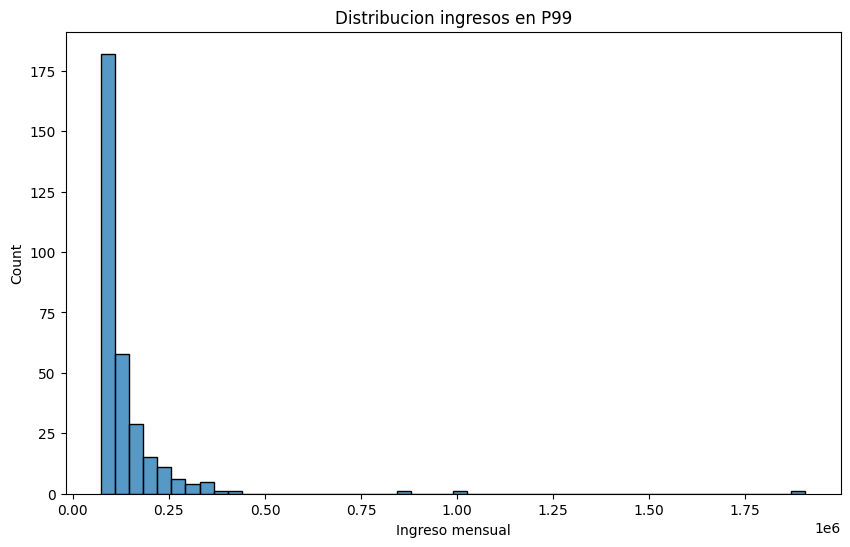

In [139]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(
    clientes_p99["AVG_ING_MENSUAL"],
    bins=50
)

plt.title("Distribucion ingresos en P99")
plt.xlabel("Ingreso mensual")
plt.show()


In [140]:
clientes_p99["AVG_ING_MENSUAL"].quantile(
    [0.25,0.50,0.75,0.90,0.95,0.99])

0.25    83,569.96
0.50    96,787.69
0.75   142,294.34
0.90   210,541.00
0.95   277,643.40
0.99   422,639.29
Name: AVG_ING_MENSUAL, dtype: float64

In [141]:
clientes_p99["AVG_ING_MENSUAL"].describe()

count         315.00
mean      134,948.07
std       134,146.71
min        72,863.34
25%        83,569.96
50%        96,787.69
75%       142,294.34
max     1,906,696.15
Name: AVG_ING_MENSUAL, dtype: float64

In [142]:
#INGRESO_CORTE = 100000

#df_bajo_medio = df_fe[
#    df_fe["AVG_ING_MENSUAL"] <= INGRESO_CORTE
#    ].copy()

#df_premium = df_fe[
#    df_fe["AVG_ING_MENSUAL"] > INGRESO_CORTE
#].copy()

#print("Dataset original:", df_fe.shape)

#print("Clientes bajos y medios:",df_bajo_medio.shape)

#print("Clientes premium:",df_premium.shape)

#print("\nPorcentaje conservado:",round(len(df_bajo_medio) / len(df_fe) * 100,2),"%")

#print("Porcentaje premium:",round(len(df_premium) / len(df_fe) * 100,2),"%")#

In [143]:
#print(df_bajo_medio["AVG_ING_MENSUAL"].describe())
#print("\n")
#print(df_premium["AVG_ING_MENSUAL"].describe())

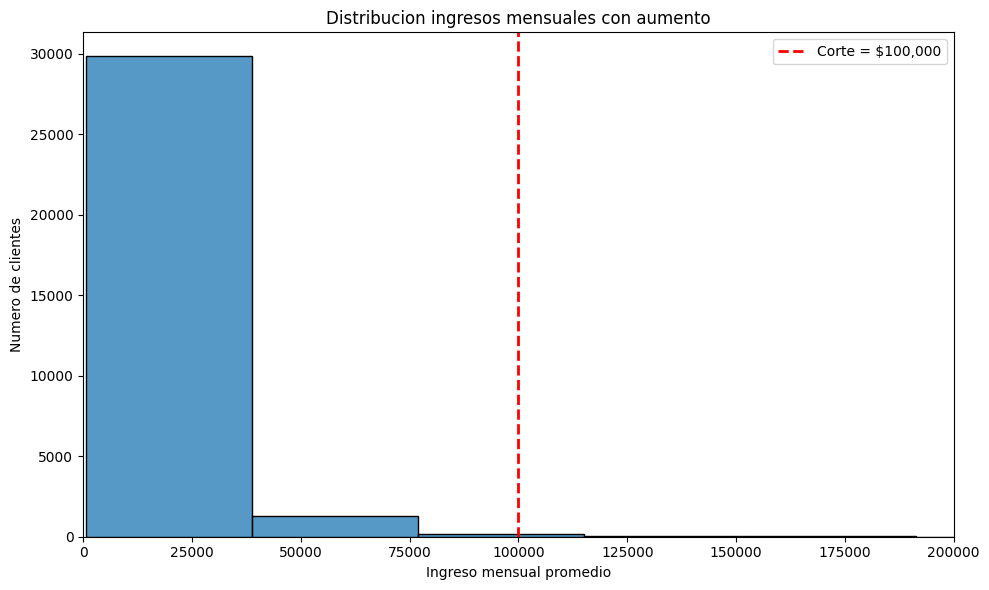

In [144]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df_fe,
    x="AVG_ING_MENSUAL",
    bins=50
)

plt.axvline(
    100000,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Corte = $100,000"
)

plt.xlim(0, 200000)

plt.title("Distribucion ingresos mensuales con aumento")

plt.xlabel("Ingreso mensual promedio")
plt.ylabel("Numero de clientes")

plt.legend()
plt.tight_layout()
plt.show()

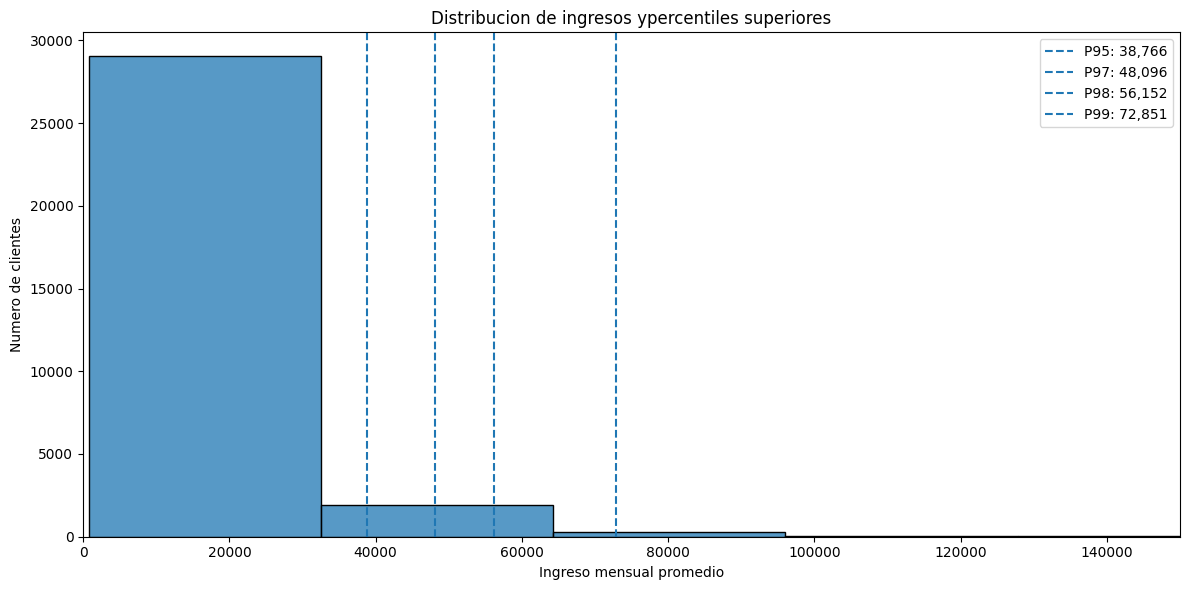

In [145]:
plt.figure(figsize=(12,6))

sns.histplot(
    df_fe["AVG_ING_MENSUAL"],
    bins=60)

for p in [95,97,98,99]:

    valor = df_fe["AVG_ING_MENSUAL"].quantile(p/100)

    plt.axvline(
        valor,
        linestyle="--",
        label=f"P{p}: {valor:,.0f}"
    )

plt.xlim(0,150000)

plt.title("Distribucion de ingresos ypercentiles superiores")

plt.xlabel("Ingreso mensual promedio")
plt.ylabel("Numero de clientes")

plt.legend()
plt.tight_layout()
plt.show()

In [146]:
percentiles = pd.DataFrame({
    "Percentil": [
        "P10",
        "P20",
        "P30",
        "P40",
        "P50",
        "P60",
        "P70",
        "P80",
        "P90",
        "P95",
        "P99"
    ],
    "Ingreso": [
        df_fe["AVG_ING_MENSUAL"].quantile(0.10),
        df_fe["AVG_ING_MENSUAL"].quantile(0.20),
        df_fe["AVG_ING_MENSUAL"].quantile(0.30),
        df_fe["AVG_ING_MENSUAL"].quantile(0.40),
        df_fe["AVG_ING_MENSUAL"].quantile(0.50),
        df_fe["AVG_ING_MENSUAL"].quantile(0.60),
        df_fe["AVG_ING_MENSUAL"].quantile(0.70),
        df_fe["AVG_ING_MENSUAL"].quantile(0.80),
        df_fe["AVG_ING_MENSUAL"].quantile(0.90),
        df_fe["AVG_ING_MENSUAL"].quantile(0.95),
        df_fe["AVG_ING_MENSUAL"].quantile(0.99)
    ]
})

percentiles

,Percentil,Ingreso
0,P10,"6,978.35"
1,P20,"8,335.92"
2,P30,"9,434.66"
3,P40,"10,664.67"
4,P50,"12,216.78"
5,P60,"14,170.39"
6,P70,"16,918.26"
7,P80,"20,866.07"
8,P90,"28,735.26"
9,P95,"38,765.83"


In [147]:
import numpy as np

rangos = pd.cut(
    df_fe["AVG_ING_MENSUAL"],
    bins=[
        0,
        25000,
        50000,
        75000,
        100000,
        150000,
        np.inf
    ]
)

tabla_rangos = (
    rangos
    .value_counts()
    .sort_index()
)

tabla_rangos

AVG_ING_MENSUAL
(0.0, 25000.0]          27117
(25000.0, 50000.0]       3436
(50000.0, 75000.0]        557
(75000.0, 100000.0]       146
(100000.0, 150000.0]       77
(150000.0, inf]            74
Name: count, dtype: int64

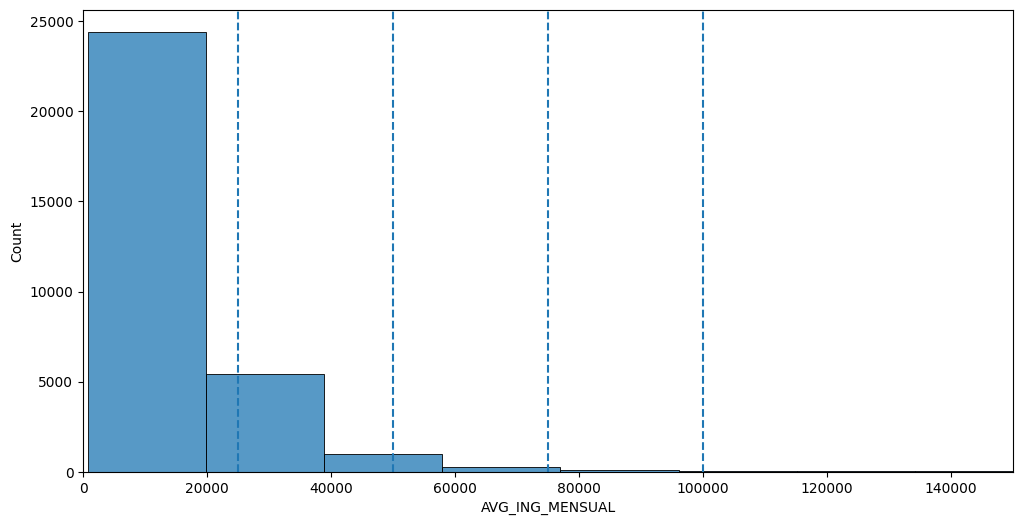

In [148]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(12,6))

sns.histplot(
    df_fe["AVG_ING_MENSUAL"],
    bins=100
)

plt.xlim(0,150000)

for corte in [
    25000,
    50000,
    75000,
    100000
]:
    
    plt.axvline(
        corte,
        linestyle="--"
    )

plt.show()

In [ ]:
segmento_ingreso = pd.cut(
    df_fe["AVG_ING_MENSUAL"],
    bins=[
        0,
        30000,
        75000,
        np.inf
    ],
    labels=[
        "Bajo",
        "Medio",
        "Alto"
    ]
)

segmento_ingreso.value_counts()

In [3]:
df_bajo_medio = df_fe[
    df_fe["AVG_ING_MENSUAL"] <= 30000
].copy()

df_alto = df_fe[
    (df_fe["AVG_ING_MENSUAL"] > 30000)
    &
    (df_fe["AVG_ING_MENSUAL"] <= 75000)
].copy()

df_premium = df_fe[
    df_fe["AVG_ING_MENSUAL"] > 75000
].copy()

In [4]:
SEGMENTO_MODELADO = "bajo_medio"

datasets_segmentos = {
    "bajo_medio": df_bajo_medio,
    "alto": df_alto,
    "premium": df_premium
}

df_modelo = datasets_segmentos[SEGMENTO_MODELADO].copy()

print("Segmento seleccionado:", SEGMENTO_MODELADO)
print("Shape df_modelo:", df_modelo.shape)

display(
    df_modelo["AVG_ING_MENSUAL"].describe()
)

Segmento seleccionado: bajo_medio
Shape df_modelo: (28549, 45)


count   28,549.00
mean    12,949.08
std      5,863.15
min        745.35
25%      8,637.17
50%     11,512.02
75%     16,317.71
max     30,000.00
Name: AVG_ING_MENSUAL, dtype: float64

In [5]:
print("Ingreso minimo:", df_modelo["AVG_ING_MENSUAL"].min())
print("Ingreso maximo:", df_modelo["AVG_ING_MENSUAL"].max())

Ingreso minimo: 745.345
Ingreso maximo: 30000.0


## Segmentacion exploratoria por nivel de ingreso

Durante el analisis de errores se observo que el desempeño del modelo no era uniforme a lo largo de todos los niveles de ingreso. En particular los mayores errores absolutos se concentraban en los deciles superiores de la distribucion de ingresos.

Con el objetivo de identificar posibles poblaciones con comportamientos diferenciados, se analizo la distribucion de la variable objetivo AVG_ING_MENSUAL mediante histogramas, percentiles y segmentación por rangos.

Los resultados mostraron que:

| Percentil | Ingreso mensual |
|------------|----------------|
| P90 | $28,735 |
| P95 | $38,766 |
| P99 | $72,851 |

Adicionalmente el histograma puso en evidencia tres zonas claramente diferenciadas:

- Una concentracion principal de clientes con ingresos menores a $30,000.
- Un grupo intermedio entre $30,000 y $75,000.
- Una cola superior compuesta por clientes de ingresos elevados y poco frecuentes.

Con base en estos hallazgos se propuso la siguiente segmentacion exploratoria:

- Segmento Bajo-Medio: ingresos menores o iguales a $30,000.
- Segmento Alto: ingresos mayores a $30,000 y menores o iguales a $75,000.
- Segmento Premium: ingresos superiores a $75,000.

Es importante mencionar que los puntos de corte no fueron definidos al azar. El primer umbral coincide aproximadamente con el percentil 90 de la distribucion, mientras que el segundo coincide aproximadamente con el percentil 99, reflejando cambios naturales en la densidad de la poblacion y en el comportamiento del error de prediccion.

Esta segmentacion busca agrupar clientes con perfiles economicos mas homogeneos y facilitar futuras estrategias de modelado especializadas para cada nivel de ingreso.

## 6.1 Definicion de variable objetivo

La variable objetivo seleccionada fue `AVG_ING_MENSUAL` correspondiente al ingreso mensual promedio del cliente.

Durante el EDA se observo que esta variable presenta una distribucion fuertemente sesgada hacia la derecha, con presencia de valores extremos elevados.

Por esta razon, se decidio aplicar una transformacion logaritmica utilizando `log1p`, buscando:

- reducir asimetría
- estabilizar varianza
- mejorar comportamiento de modelos sensibles a escalamiento
- reducir impacto de outliers extremos

In [8]:
df_modelo=df_fe.copy()

In [9]:
import numpy as np

y = np.log1p(df_modelo["AVG_ING_MENSUAL"]) #y = np.log1p(df_fe["AVG_ING_MENSUAL"])

X = df_modelo.drop( #X = df_fe.drop(
    columns=["AVG_ING_MENSUAL"]
)

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (28552, 87)
Shape y: (28552,)


## 6.2 Particionamiento del dataset

El dataset fue dividido en tres subconjuntos:

- entrenamiento (60%)
- validación (20%)
- prueba (20%)

Esto permite:

- entrenar modelos
- ajustar hiperparametros

El particionamiento se realizo antes de aplicar imputacion, escalamiento y codificacion categorica, evitando data leakage.

In [10]:
from sklearn.model_selection import train_test_split

Xtrain, Xtv, ytrain, ytv = train_test_split(
    X,
    y,
    train_size=0.6,
    shuffle=True,
    random_state=42
)

Xval, Xtest, yval, ytest = train_test_split(
    Xtv,
    ytv,
    test_size=0.5,
    shuffle=True,
    random_state=42
)

print("Train:", Xtrain.shape, ytrain.shape)
print("Validation:", Xval.shape, yval.shape)
print("Test:", Xtest.shape, ytest.shape)

Train: (17131, 87) (17131,)
Validation: (5710, 87) (5710,)
Test: (5711, 87) (5711,)


In [43]:
variables_ratios = [
    "RATIO_SALDO_ACTUAL_MONTO",
    "RATIO_SALDO_VENCIDO_ACTUAL"
]

numericas = Xtrain.select_dtypes(
    include=["int64", "float64", "int32", "float32", "int16", "float16", "bool"]
).columns.tolist()

categoricas = Xtrain.select_dtypes(
    include=["object", "category"]
).columns.tolist()

#pendiente validar que coincida con 02_FeatureEngieering_ProyectoFinal
print("Variables numericas:", len(numericas))
print("Variables categoricas:", len(categoricas))
print("Variables ratios:", variables_ratios)

Variables numericas: 82
Variables categoricas: 5
Variables ratios: ['RATIO_SALDO_ACTUAL_MONTO', 'RATIO_SALDO_VENCIDO_ACTUAL']


In [44]:
variables_log = [
    "SUM_MONTO_OTORG",
    "SUM_TL_SALDO_ACTUAL",
    "SUM_TL_SALDO_VENCIDO",
    "AVG_DAYS_FREQ",
    "MEDIANA_DAYS_FREQ",
    "SUM_LIM_CRED_TDC",
    "SUM_SALDO_TDC",
    'SUM_LIM_CRED_TDC_ACTUAL',
    'SUM_TL_SALDO_ACTUAL',
    'SUM_SDO_VDO_ACTUAL',
    'TVIVHAB'
    # 'MAX_MTO_LIM_CRED_ANTICIPOS'
]

variables_log = [
    col for col in variables_log
    if col in Xtrain.columns
]

variables_num_sin_log = [
    col for col in numericas
    if col not in variables_log
]

print("Variables con log1p:", len(variables_log))
print(variables_log)

print("\nVariables numericas sin log1p:", len(variables_num_sin_log))

Variables con log1p: 8
['SUM_MONTO_OTORG', 'SUM_TL_SALDO_ACTUAL', 'SUM_TL_SALDO_VENCIDO', 'SUM_LIM_CRED_TDC', 'SUM_LIM_CRED_TDC_ACTUAL', 'SUM_TL_SALDO_ACTUAL', 'SUM_SDO_VDO_ACTUAL', 'TVIVHAB']

Variables numericas sin log1p: 75


In [45]:
limites_ratios = {}

for col in variables_ratios:
    limite_superior = Xtrain[col].quantile(0.995)
    limites_ratios[col] = limite_superior
    
    print(f"{col} limite P99.5 aprendido en Xtrain: {limite_superior:.2f}")

RATIO_SALDO_ACTUAL_MONTO limite P99.5 aprendido en Xtrain: 1.79
RATIO_SALDO_VENCIDO_ACTUAL limite P99.5 aprendido en Xtrain: 2.98


In [46]:
for df in [Xtrain, Xval, Xtest]:
    df["FLAG_RATIO_SALDO_ACTUAL_ALTO"] = (
        df["RATIO_SALDO_ACTUAL_MONTO"] > limites_ratios["RATIO_SALDO_ACTUAL_MONTO"]
    ).astype(int)

    df["FLAG_RATIO_VENCIDO_ALTO"] = (
        df["RATIO_SALDO_VENCIDO_ACTUAL"] > limites_ratios["RATIO_SALDO_VENCIDO_ACTUAL"]
    ).astype(int)

In [47]:
for df in [Xtrain, Xval, Xtest]:
    for col in variables_ratios:
        df[col] = np.where(
            df[col] > limites_ratios[col],
            limites_ratios[col],
            df[col]
        )

In [48]:
Xtrain[variables_ratios + [
    "FLAG_RATIO_SALDO_ACTUAL_ALTO",
    "FLAG_RATIO_VENCIDO_ALTO"
]].describe(
    percentiles=[0.90, 0.95, 0.99, 0.995]
).T

,count,mean,std,min,50%,90%,95%,99%,99.5%,max
RATIO_SALDO_ACTUAL_MONTO,"17,131.00",0.34,0.32,0.00,0.26,0.80,0.93,1.40,1.79,1.79
RATIO_SALDO_VENCIDO_ACTUAL,"17,131.00",0.33,0.47,0.00,0.06,1.00,1.10,1.88,2.97,2.98
FLAG_RATIO_SALDO_ACTUAL_ALTO,"17,131.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
FLAG_RATIO_VENCIDO_ALTO,"17,131.00",0.01,0.07,0.00,0.00,0.00,0.00,0.00,0.35,1.00


In [49]:
# VARIABLES NUMERICAS Y CATEGORICAS

numericas = Xtrain.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categoricas = Xtrain.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numericas:", len(numericas))
print("Categoricas:", len(categoricas))

Numericas: 76
Categoricas: 5


In [50]:
print("\n NUMERICAS ")
print(numericas)

print("\n CATEGORICAS ")
print(categoricas)


 NUMERICAS 
['ANTIGUEDAD_CLIENTE_ANIOS', 'AVG_FREQ_APER_ANTICIPOS', 'AVG_FREQ_APER_NCC', 'AVG_MESES_ENTRE_CUENTAS_APER', 'AVG_VIGENCIA_ANTICIPOS', 'AVG_VIGENCIA_NCC', 'CAP_PAGO_TDC', 'COUNT_12M', 'COUNT_6M', 'COUNT_ANTICIPOS', 'COUNT_AUTOCONS', 'COUNT_DIST_CTO', 'COUNT_DIST_OTORG', 'COUNT_FLAG_12M', 'COUNT_FLAG_AU', 'COUNT_FLAG_CC', 'COUNT_FLAG_CLOSED', 'COUNT_FLAG_MAS_24M', 'COUNT_FLAG_SALDO_VDO', 'COUNT_MAS_24M', 'COUNT_TDC_ACTUAL', 'COUNT_TDC_TIENDAS_ACTUAL', 'EDAD', 'FLAG_ACTUAL_ANTICIPOS', 'FLAG_ACTUAL_SDO_VDO', 'FLAG_ANTICIPO_NOMINA', 'FLAG_CAMBIO_12M', 'FLAG_HIST_ANTICIPOS', 'FLAG_HIST_NCC', 'GRAPROES', 'MAX_ANTIG_TDC', 'MAX_MESES_ENTRE_CUENTAS_APER', 'MAX_PEOR_MOP_IN_12M', 'MIN_MESES_ENTRE_CUENTAS_APER', 'NUM_DIF_CONS', 'NUM_DIF_TRAM', 'NUM_EMPRESAS', 'PCNT_ESCUELAS_PRIV', 'PCNT_FORMAL', 'PCNT_HOSP_PRIV', 'PCNT_MICRONEG', 'PCNT_POB_DESOCUP', 'PCNT_POB_INTER', 'PCNT_SDO_ACTUAL_ANTICIPOS', 'PCNT_SDO_ACTUAL_NCC', 'PCNT_SDO_ACTUAL_TDC', 'PCNT_VIV_AUTOM', 'PROM_HNV', 'RATIO_CONSULT

In [51]:
variables_log = [
    "SUM_MONTO_OTORG",
    "SUM_TL_SALDO_ACTUAL",
    "SUM_TL_SALDO_VENCIDO",
    "AVG_DAYS_FREQ",
    "MEDIANA_DAYS_FREQ",
    "SUM_LIM_CRED_TDC",
    "SUM_SALDO_TDC",
    'SUM_LIM_CRED_TDC_ACTUAL',
    'SUM_TL_SALDO_ACTUAL',
    'SUM_SDO_VDO_ACTUAL',
    'TVIVHAB'
    # 'MAX_MTO_LIM_CRED_ANTICIPOS'
]

variables_log = [
    col for col in variables_log
    if col in Xtrain.columns
]

variables_num_sin_log = [
    col for col in numericas
    if col not in variables_log
]

print("Variables con log1p:", len(variables_log))
print(variables_log)

print("\nVariables numericas sin log1p:", len(variables_num_sin_log))

Variables con log1p: 8
['SUM_MONTO_OTORG', 'SUM_TL_SALDO_ACTUAL', 'SUM_TL_SALDO_VENCIDO', 'SUM_LIM_CRED_TDC', 'SUM_LIM_CRED_TDC_ACTUAL', 'SUM_TL_SALDO_ACTUAL', 'SUM_SDO_VDO_ACTUAL', 'TVIVHAB']

Variables numericas sin log1p: 69


## 6.2.1 Seleccion inicial de caracteristicas por baja varianza

Antes de construir el pipeline de transformacion, se realizo una revision de variables con baja variabilidad utilizando exclusivamente el conjunto de entrenamiento.

Este procedimiento permite identificar variables constantes o casi constantes que aportan poca informacion al modelo y pueden incrementar innecesariamente la complejidad del entrenamiento.

Para evitar data leakage, cualquier criterio de seleccion fue calculado unicamente sobre `Xtrain` y posteriormente aplicado de forma consistente a validacion y prueba.

In [52]:
constantes = [
    col for col in Xtrain.columns
    if Xtrain[col].nunique(dropna=False) <= 1
]

print("Variables constantes:")
print(constantes)

print("\nCantidad:", len(constantes))

Variables constantes:
['FLAG_RATIO_SALDO_ACTUAL_ALTO']

Cantidad: 1


In [53]:
umbral_dominancia = 0.99

casi_constantes = []

for col in Xtrain.columns:
    
    proporcion_mayoritaria = Xtrain[col].value_counts(
        normalize=True,
        dropna=False
    ).iloc[0]
    
    if proporcion_mayoritaria >= umbral_dominancia:
        
        casi_constantes.append({
            "Variable": col,
            "Proporcion": proporcion_mayoritaria
        })

casi_constantes_df = pd.DataFrame(casi_constantes)

casi_constantes_df.sort_values(
    by="Proporcion",
    ascending=False
)

,Variable,Proporcion
3,FLAG_RATIO_SALDO_ACTUAL_ALTO,1.00
0,FLAG_ACTUAL_ANTICIPOS,1.00
1,PCNT_SDO_ACTUAL_ANTICIPOS,1.00
2,FLAG_RATIO_VENCIDO_ALTO,0.99


In [54]:
#VARIABLES A ELIMINAR POR BAJA VARIANZA

cols_baja_varianza = constantes.copy()

print(cols_baja_varianza)

Xtrain = Xtrain.drop(
    columns=cols_baja_varianza,
    errors="ignore"
)

Xval = Xval.drop(
    columns=cols_baja_varianza,
    errors="ignore"
)

Xtest = Xtest.drop(
    columns=cols_baja_varianza,
    errors="ignore"
)

print("Xtrain:", Xtrain.shape)
print("Xval:", Xval.shape)
print("Xtest:", Xtest.shape)

['FLAG_RATIO_SALDO_ACTUAL_ALTO']
Xtrain: (17131, 87)
Xval: (5710, 87)
Xtest: (5711, 87)


### Consideraciones sobre transformaciones adicionales

Durante esta etapa se evaluo la posibilidad de aplicar transformaciones adicionales como Box-Cox o Yeo-Johnson sobre variables monetarias y variables altamente sesgadas.

Sin embargo, para esta primera version del baseline se decidio mantener un enfoque mas interpretable y controlado, priorizando:

- limpieza estructural
- tratamiento de valores extremos
- reducción de leakage
- estabilidad del pipeline.

La transformacion logaritmica fue aplicada sobre la variable objetivo (`AVG_ING_MENSUAL`) debido a su fuerte asimetria positiva observada durante el EDA.

Transformaciones adicionales podran evaluarse posteriormente como parte de la optimizacion de modelos mas avanzados.

## Conclusiones de la fase de preparacion de datos e ingenieria de caracteristicas

La etapa de preparacion de datos permitio transformar el dataset maestro en una base mas consistente y adecuada para modelado supervisado.

Durante esta fase se realizaron actividades de limpieza estructural, reduccion de cardinalidad, tratamiento de valores extremos, deteccion de posibles fuentes de leakage y construccion de nuevas variables orientadas al negocio.

Entre los principales hallazgos destacan:

- fuerte asimetria positiva en la variable objetivo
- presencia de valores extremos en variables monetarias y de movilidad
- alta multicolinealidad entre variables temporales y de comportamiento crediticio
- posibles inconsistencias temporales en algunas variables de nomina
- errores potenciales de scraping y geocodificacion

Se construyeron variables derivadas relacionadas con:

- estabilidad financiera
- antiguedad del cliente
- comportamiento crediticio
- movilidad geografica
- calidad de informacion
- indicadores de riesgo.

En el contexto de la metodologia CRISP-ML(Q) esta etapa contribuyo a mejorar la calidad, trazabilidad e interpretabilidad del dataset previo al modelado. Todas las decisiones fueron documentadas y justificadas utilizando tanto evidencia estadistica como validacion con conocimiento de negocio.

In [ ]:
df_fe.to_csv("df_final_pre_modelado.csv",index=False,encoding="utf-8-sig")

## 7 Construccion del pipeline de transformacion

Una vez realizado el particionamiento del dataset, se construyo un pipeline de transformacion utilizando `scikit-learn`.

El pipeline tiene como objetivo:

- imputar valores faltantes
- codificar variables categoricas
- escalar variables numericas
- garantizar reproducibilidad
- evitar data leakage

Las transformaciones se ajustan unicamente sobre el conjunto de entrenamiento y posteriormente se aplican a validacion y prueba.

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

Antes de construir el pipeline de transformacion, se revisaron los tipos de datos presentes en los conjuntos de entrenamiento, validacion y prueba.

In [55]:
numericas = Xtrain.select_dtypes(
    include=["int64", "float64", "int32", "float32", "int16", "float16", "bool"]
).columns.tolist()

categoricas = Xtrain.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numericas:", len(numericas))
print("Categóoricas:", len(categoricas))
print("Total seleccionadas:", len(numericas) + len(categoricas))
print("Total columnas Xtrain:", Xtrain.shape[1])

columnas_no_incluidas = set(Xtrain.columns) - set(numericas) - set(categoricas)
print("Columnas no incluidas:")
print(columnas_no_incluidas)

Numericas: 82
Categóoricas: 5
Total seleccionadas: 87
Total columnas Xtrain: 87
Columnas no incluidas:
set()


Diagnostico de distribuciones y variables extremas

In [29]:
skewness = Xtrain[numericas].skew().sort_values(
    ascending=False
)

skewness.head(20)

SUM_SALDO_ANTICIPOS_ACTUAL    94.570088
PCNT_SDO_ACTUAL_ANTICIPOS     76.942377
SUM_TL_SALDO_VENCIDO          71.239145
FLAG_ACTUAL_ANTICIPOS         58.513245
SUM_LIM_CRED_TDC_ACTUAL       58.327291
SUM_SDO_ACTUAL                46.930847
COUNT_TDC_TIENDAS_ACTUAL      44.068232
SUM_LIM_CRED_TDC              36.025781
SUM_SALDO_TDC_ACTUAL          31.539036
RATIO_DIST_BANCO_EMPENIO      19.845376
SUM_TL_SALDO_ACTUAL           18.618662
SUM_MONTO_OTORG               17.542169
COUNT_MAS_24M                 16.949255
FLAG_RATIO_VENCIDO_ALTO       14.008465
SUM_SDO_VDO_ACTUAL            13.726440
min_dist_n_escuelas           13.191406
AVG_VIGENCIA_ANTICIPOS        12.871850
min_dist_n_gimnasios          11.326966
SUM_SALDO_NCC_ACTUAL          10.341506
min_dist_n_restaurantes       10.190823
dtype: float64

In [56]:
from sklearn.preprocessing import FunctionTransformer


pipeline_num_log = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scaler", StandardScaler())
])

pipeline_num_sin_log = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

pipeline_cat = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore",drop='first')) # drop="first"
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num_log", pipeline_num_log, variables_log),
        ("num", pipeline_num_sin_log, variables_num_sin_log),
        ("cat", pipeline_cat, categoricas)
    ],
    remainder="drop"
)

In [ ]:
preprocessor

ColumnTransformer(transformers=[('num_log',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('log1p',
                                                  FunctionTransformer(feature_names_out='one-to-one',
                                                                      func=<ufunc 'log1p'>)),
                                                 ('scaler', StandardScaler())]),
                                 ['SUM_MONTO_OTORG', 'SUM_TL_SALDO_ACTUAL',
                                  'SUM_TL_SALDO_VENCIDO',
                                  'MEDIANA_DAYS_FREQ']),
                                ('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(...
                                  'MIN_MESES_ENTRE_CUENTAS_APER',
                                  'COUNT_DIST_OTORG', 'COUNT_DIST_CTO', 'EDAD',
                                  'ANTIGUEDAD_CLIENTE_ANIOS',
                                  'ANTIGUEDAD_NOMINA_MESES',
                                  'RATIO_SALDO_ACTUAL_MONTO',
                                  'RATIO_SALDO_VENCIDO_ACTUAL', ...]),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 ['SEXO', 'ESTADO_CIVIL', 'traffic_mode',
                                  'REGION'])])

### 7.4 Ajuste del preprocesador

El preprocessor se ajusto exclusivamente con `Xtrain`. Esto permite que los parametros de imputacion, escalamiento y codificacion categorica se aprendan solo a partir de los datos de entrenamiento. Despues, el mismo objeto ajustado se utilizo para transformar los conjuntos de validación y prueba.

In [97]:
preprocessor.fit(Xtrain)

XtrainFit = preprocessor.transform(Xtrain)
XvalFit = preprocessor.transform(Xval)
XtestFit = preprocessor.transform(Xtest)

In [98]:
print("Train transformado:", XtrainFit.shape)
print("Validation transformado:", XvalFit.shape)
print("Test transformado:", XtestFit.shape)

Train transformado: (17131, 92)
Validation transformado: (5710, 92)
Test transformado: (5711, 92)


### 7.5 Definicion de metricas de evaluacion

Debido a que el objetivo del proyecto es estimar el ingreso mensual de los clientes, el problema se formulo como una tarea de regresion supervisada. La variable objetivo fue transformada mediante `log1p` para reducir el efecto de la asimetria positiva y de los valores extremos observados en el analisis exploratorio.

Para evaluar el desempeño del modelo se utilizaron metricas tanto en escala logaritmica como en escala original. Las metricas en escala logaritmica permiten analizar la capacidad predictiva del modelo sobre la variable transformada, mientras que las metricas en escala original facilitan la interpretacion en terminos monetarios.

Las metricas consideradas fueron:

- MAE: error absoluto promedio.
- RMSE: penaliza con mayor fuerza errores grandes.
- R²: proporcion de variabilidad explicada por el modelo.
- MAPE: error porcentual absoluto promedio util para interpretacion de negocio, debe analizarse con atencion cuando existen ingresos bajos.

In [93]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor

from sklearn.linear_model import Ridge

#### Avance 4. Modelos alternativos


In [94]:
from sklearn.model_selection import GridSearchCV

import time


#Lasso regresor
from sklearn.linear_model import Lasso

#Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor

#KNN Regressor
from sklearn.neighbors import KNeighborsRegressor

#Support Vector Regressor
from sklearn.svm import SVR

#Ridge Polinomica
from sklearn.preprocessing import PolynomialFeatures

#Lasso Polinomica


### 1. Lasso Regressor

Se evalua Lasso Regression como modelo lineal regularizado mediante penalizacion L1. 
Este modelo es importante porque permite controlar la complejidad del modelo y puede reducir el peso de variables poco relevantes.

Dado que el problema consiste en estimar ingresos mensuales en escala logaritmica, Lasso se utiliza como alternativa al modelo Ridge baseline para evaluar si una regularizacion mas agresiva mejora el desempeño predictivo.

In [95]:
#pipeline_lasso = Pipeline(steps=[
#    ("preprocessor", preprocessor),
#    ("model", Lasso(random_state=42, max_iter=10000))
#])

param_grid = {
    'alpha': [0.0001, 0.001, 0.01, 0.02, 0.03, 0.05, 0.1, 0.5, 1.0]
}

lasso = Lasso(
    random_state=42,
    max_iter=10000
)

grid_search_lasso = GridSearchCV(
    estimator=lasso, 
    param_grid=param_grid, 
    cv=5, 
    scoring='neg_mean_squared_error'
    )

In [99]:
inicio_lasso = time.time()

grid_search_lasso.fit(XtrainFit, ytrain)

tiempo_lasso = time.time() - inicio_lasso

In [100]:
print("Mejores hiperparametros Lasso:")
print(grid_search_lasso.best_params_)

print("Mejor score CV:")
print(grid_search_lasso.best_score_)

print("\nTiempo de entrenamiento:")
print(round(tiempo_lasso, 2), "segundos")

Mejores hiperparametros Lasso:
{'alpha': 0.01}
Mejor score CV:
-0.19259799105003558

Tiempo de entrenamiento:
2.68 segundos


In [101]:
pred_train_lasso_log = grid_search_lasso.predict(XtrainFit)
pred_val_lasso_log = grid_search_lasso.predict(XvalFit)

In [102]:
mae_train_lasso_log = mean_absolute_error(
    ytrain,
    pred_train_lasso_log
)

rmse_train_lasso_log = np.sqrt(mean_squared_error(
    ytrain, 
    pred_train_lasso_log)
)

r2_train_lasso_log = r2_score(
    ytrain,
    pred_train_lasso_log
)

#Val
mae_val_lasso_log = mean_absolute_error(
    yval,
    pred_val_lasso_log
)

rmse_val_lasso_log = np.sqrt(mean_squared_error(
    yval, 
    pred_val_lasso_log)
)

r2_val_lasso_log = r2_score(
    yval,
    pred_val_lasso_log
)

In [103]:
print("Lasso Regression escala logaritmica")

print("\nTRAIN")
print("MAE log:", mae_train_lasso_log)
print("RMSE log:", rmse_train_lasso_log)
print("R2 log:", r2_train_lasso_log)

print("\nVALIDATION")
print("MAE log:", mae_val_lasso_log)
print("RMSE log:", rmse_val_lasso_log)
print("R2 log:", r2_val_lasso_log)

Lasso Regression escala logaritmica

TRAIN
MAE log: 0.3406619386297533
RMSE log: 0.43795945501753825
R2 log: 0.124931376575111

VALIDATION
MAE log: 0.3394518387068161
RMSE log: 0.4401556459559948
R2 log: 0.10876829213554895


Cuando RMSE es mayor que MAE significa que existen algunos errores grandes.El modelo tiene errores promedio moderados pero algunos clientes presentan errores mas grandes, muy probablemente en ingresos altos o perfiles que sn atipicos.

El modelo explica cerca del 10% de la variabilidad del ingreso mensual (R2) en el conjunto de validacion. 

In [104]:
pred_train_lasso = np.expm1(pred_train_lasso_log)
pred_val_lasso = np.expm1(pred_val_lasso_log)

ytrain_original = np.expm1(ytrain)
yval_original = np.expm1(yval)

mae_train_lasso = mean_absolute_error(
    ytrain_original,
    pred_train_lasso
)

rmse_train_lasso = np.sqrt(mean_squared_error(
    ytrain_original,
    pred_train_lasso
))

mae_val_lasso = mean_absolute_error(
    yval_original,
    pred_val_lasso
)

rmse_val_lasso = np.sqrt(mean_squared_error(
    yval_original,
    pred_val_lasso
))

print("\nLasso Regression escala original")

print("\nTRAIN")
print("MAE:", mae_train_lasso)
print("RMSE:", rmse_train_lasso)

print("\nVALIDATION")
print("MAE:", mae_val_lasso)
print("RMSE:", rmse_val_lasso)


Lasso Regression escala original

TRAIN
MAE: 4219.605331313309
RMSE: 5593.660080703377

VALIDATION
MAE: 4198.4677449744595
RMSE: 5614.761438067907


En promedio el modelo se equivoca aproximadamente en $5,614 mxn al estimar el ingreso mensual de un cliente en validacion

El RMSE es mayor que el MAE ya que castiga mas errores grandes. Aunque el error promedio tipico es de alrededor de $5,614 mxn existen casos donde el error es considerablemente mayor lo cual eleva el RMSE (algunos clientes tienen ingresos muy altos). 

In [105]:
gap_r2_lasso = abs(
    r2_train_lasso_log -
    r2_val_lasso_log
)

print("Gap R2:", round(gap_r2_lasso,4))

Gap R2: 0.0162


El modelo presento un Gap R2 de 0.0162 entre entrenamiento y validacion. Este valor es considerablemente bajo y nos sugiere que el modelo mantiene un comportamiento consistente en datos no observados y sin evidencia de sobreajuste.

El gap nos ayuda la diferencia entre desempeño en train y validation. Nunca debemos tener Train > Validacion. un Gap entre 0.10 y 0.20 es para analizar un posible sobreajuste

### 2. Decision Tree Regressor

Se evalua un arbol de decision para regresion como modelo no lineal e interpretable. 
A diferencia modelos lineales este algoritmo puede capturar relaciones no lineales entre las variables explicativas y el ingreso mensual estimado.

Sin embargo los arboles de decision pueden sobreajustarse muy facil, entonces se utilizara GridSearchCV para controlar hiperparametros.

In [139]:
dtree = DecisionTreeRegressor(random_state=42)


param_grid = {
    'criterion': ['squared_error', 'absolute_error'],
    'max_depth': [3, 5, 7, 10, 15, 20], #[3, 5, 7, 10, 15, 20]
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [5, 10, 20, 50, 100] #[5, 10, 20, 50, 100]
}

grid_search_dt = GridSearchCV(
    estimator=dtree, 
    param_grid=param_grid, 
    cv=5, 
    scoring='neg_mean_squared_error'
    )

In [140]:
inicio_dt = time.time()

grid_search_dt.fit(XtrainFit, ytrain)

tiempo_dt = time.time() - inicio_dt

In [141]:
print("Mejores hiperparametros Decision Tree:")
print(grid_search_dt.best_params_)

print("Mejor score CV:")
print(grid_search_dt.best_score_)

print("\nTiempo de entrenamiento:")
print(round(tiempo_dt, 2), "segundos")

Mejores hiperparametros Decision Tree:
{'criterion': 'squared_error', 'max_depth': 10, 'min_samples_leaf': 100, 'min_samples_split': 2}
Mejor score CV:
-0.2025287429637262

Tiempo de entrenamiento:
1.88 segundos


In [142]:
pred_train_dt_log = grid_search_dt.predict(XtrainFit)
pred_val_dt_log = grid_search_dt.predict(XvalFit)

In [143]:
mae_train_dt_log = mean_absolute_error(
    ytrain,
    pred_train_dt_log
)

rmse_train_dt_log = np.sqrt(mean_squared_error(
    ytrain, 
    pred_train_dt_log)
)

r2_train_dt_log = r2_score(
    ytrain,
    pred_train_dt_log
)

#Val
mae_val_dt_log = mean_absolute_error(
    yval,
    pred_val_dt_log
)

rmse_val_dt_log = np.sqrt(mean_squared_error(
    yval, 
    pred_val_dt_log)
)

r2_val_dt_log = r2_score(
    yval,
    pred_val_dt_log
)

In [144]:
print("Decision Tree escala logaritmica")

print("\nTRAIN")
print("MAE log:", mae_train_dt_log)
print("RMSE log:", rmse_train_dt_log)
print("R2 log:", r2_train_dt_log)

print("\nVALIDATION")
print("MAE log:", mae_val_dt_log)
print("RMSE log:", rmse_val_dt_log)
print("R2 log:", r2_val_dt_log)

Decision Tree escala logaritmica

TRAIN
MAE log: 0.33109739346098094
RMSE log: 0.42584871499583454
R2 log: 0.1726581733541802

VALIDATION
MAE log: 0.3449035891460239
RMSE log: 0.44712921567814173
R2 log: 0.08030426829465465


In [145]:
pred_train_dt = np.expm1(pred_train_dt_log)
pred_val_dt = np.expm1(pred_val_dt_log)

mae_train_dt = mean_absolute_error(
    ytrain_original,
    pred_train_dt
)

rmse_train_dt = np.sqrt(mean_squared_error(
    ytrain_original,
    pred_train_dt
))

mae_val_dt = mean_absolute_error(
    yval_original,
    pred_val_dt
)

rmse_val_dt = np.sqrt(mean_squared_error(
    yval_original,
    pred_val_dt
))

print("\nDecision Tree escala original")

print("\nTRAIN")
print("MAE:", mae_train_dt)
print("RMSE:", rmse_train_dt)

print("\nVALIDATION")
print("MAE:", mae_val_dt)
print("RMSE:", rmse_val_dt)


Decision Tree escala original

TRAIN
MAE: 4105.83347316191
RMSE: 5427.370993844165

VALIDATION
MAE: 4263.489048461875
RMSE: 5657.89174771372


### 3. KNN Regressor

Este algoritmo estima el ingreso de un cliente utilizando los ingresos de clientes similares dentro del espacio de variables transformadas.

Dado que KNN depende fuertemente de las distancias entre observaciones es importante que las variables numericas esten escaladas, lo cual ya fue considerado previamente dentro del pipeline de preprocesamiento.

In [146]:
knn = KNeighborsRegressor()

param_grid = {
    'n_neighbors': [10, 15, 20, 30, 35,40,50],
    # 'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan','minkowski']
}


grid_search_knn = GridSearchCV(
    estimator=knn, 
    param_grid=param_grid, 
    cv=5, 
    scoring='neg_mean_squared_error'
    )

In [147]:
inicio_knn = time.time()

grid_search_knn.fit(XtrainFit, ytrain)

tiempo_knn = time.time() - inicio_knn

In [148]:
print("Mejores hiperparametros KNN Regressor:")
print(grid_search_knn.best_params_)

print("Mejor score CV:")
print(grid_search_knn.best_score_)

print("\nTiempo de entrenamiento:")
print(round(tiempo_knn, 2), "segundos")

Mejores hiperparametros KNN Regressor:
{'metric': 'manhattan', 'n_neighbors': 35}
Mejor score CV:
-0.1885364466912317

Tiempo de entrenamiento:
5.05 segundos


In [154]:
pred_train_knn_log = grid_search_knn.predict(XtrainFit)
pred_val_knn_log = grid_search_knn.predict(XvalFit)

In [157]:
mae_train_knn_log = mean_absolute_error(
    ytrain,
    pred_train_knn_log
)

rmse_train_knn_log = np.sqrt(mean_squared_error(
    ytrain, 
    pred_train_knn_log)
)

r2_train_knn_log = r2_score(
    ytrain,
    pred_train_knn_log
)

#Val
mae_val_knn_log = mean_absolute_error(
    yval,
    pred_val_knn_log
)

rmse_val_knn_log = np.sqrt(mean_squared_error(
    yval, 
    pred_val_knn_log)
)

r2_val_knn_log = r2_score(
    yval,
    pred_val_knn_log
)

In [158]:
print("KNN escala logaritmica")

print("\nTRAIN")
print("MAE log:", mae_train_knn_log)
print("RMSE log:", rmse_train_knn_log)
print("R2 log:", r2_train_knn_log)

print("\nVALIDATION")
print("MAE log:", mae_val_knn_log)
print("RMSE log:", rmse_val_knn_log)
print("R2 log:", r2_val_knn_log)

KNN escala logaritmica

TRAIN
MAE log: 0.32712382256427236
RMSE log: 0.42096139146299666
R2 log: 0.19153945283807627

VALIDATION
MAE log: 0.3333657835167485
RMSE log: 0.43332252292092965
R2 log: 0.13622505739836144


In [159]:
gap_r2_knn = abs(r2_train_knn_log - r2_val_knn_log)

print("Gap R2:", round(gap_r2_knn, 4))

Gap R2: 0.0553


In [160]:
pred_train_knn = np.expm1(pred_train_knn_log)
pred_val_knn = np.expm1(pred_val_knn_log)

mae_train_knn = mean_absolute_error(
    ytrain_original,
    pred_train_knn
)

rmse_train_knn = np.sqrt(mean_squared_error(
    ytrain_original,
    pred_train_knn
))

mae_val_knn = mean_absolute_error(
    yval_original,
    pred_val_knn
)

rmse_val_knn = np.sqrt(mean_squared_error(
    yval_original,
    pred_val_knn
))

print("\nKNN escala original")

print("\nTRAIN")
print("MAE:", mae_train_knn)
print("RMSE:", rmse_train_knn)

print("\nVALIDATION")
print("MAE:", mae_val_knn)
print("RMSE:", rmse_val_knn)


KNN escala original

TRAIN
MAE: 4060.417919608834
RMSE: 5450.210471908002

VALIDATION
MAE: 4118.816800676075
RMSE: 5544.796598229614


### 4. Support Vector Regressor

Este modelo puede capturar relaciones complejas entre las variables explicativas y el ingreso mensual mediante el uso de kernels.

In [348]:
svr=SVR()
param_grid = {
    'kernel': ['rbf'],
    'C': [0.1],
    'gamma': [ 'auto'], #['scale', 'auto'] , [0.01, 0.1]
    'epsilon': [0.2]
}


grid_search_svr = GridSearchCV(
    estimator=svr,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
)

In [349]:
inicio_svr = time.time()

grid_search_svr.fit(XtrainFit, ytrain)

tiempo_svr = time.time() - inicio_svr

In [350]:
pred_train_svr_log = grid_search_svr.predict(XtrainFit)
pred_val_svr_log = grid_search_svr.predict(XvalFit)

In [351]:
print("Mejores hiperparametros SVR:")
print(grid_search_svr.best_params_)

print("Mejor score CV:")
print(grid_search_svr.best_score_)

print("\nTiempo de entrenamiento:")
print(round(tiempo_svr, 2), "segundos")

Mejores hiperparametros SVR:
{'C': 0.1, 'epsilon': 0.2, 'gamma': 'auto', 'kernel': 'rbf'}
Mejor score CV:
-0.17987203524330983

Tiempo de entrenamiento:
59.5 segundos


In [352]:
mae_train_svr_log = mean_absolute_error(
    ytrain,
    pred_train_svr_log
)

rmse_train_svr_log = np.sqrt(mean_squared_error(
    ytrain,
    pred_train_svr_log
))

r2_train_svr_log = r2_score(
    ytrain,
    pred_train_svr_log
)

mae_val_svr_log = mean_absolute_error(
    yval,
    pred_val_svr_log
)

rmse_val_svr_log = np.sqrt(mean_squared_error(
    yval,
    pred_val_svr_log
))

r2_val_svr_log = r2_score(
    yval,
    pred_val_svr_log
)

In [353]:
gap_r2_svr = abs(r2_train_svr_log - r2_val_svr_log)

print("Gap R2:", round(gap_r2_svr, 4))

Gap R2: 0.0856


In [354]:
print("SVR escala logaritmica")

print("\nTRAIN")
print("MAE log:", mae_train_svr_log)
print("RMSE log:", rmse_train_svr_log)
print("R2 log:", r2_train_svr_log)

print("\nVALIDATION")
print("MAE log:", mae_val_svr_log)
print("RMSE log:", rmse_val_svr_log)
print("R2 log:", r2_val_svr_log)

print("\nGap R2:", round(gap_r2_svr, 4))

SVR escala logaritmica

TRAIN
MAE log: 0.30877883027425873
RMSE log: 0.40544938589045465
R2 log: 0.2500236083151117

VALIDATION
MAE log: 0.32320760676681054
RMSE log: 0.4261991441123014
R2 log: 0.16439078301459986

Gap R2: 0.0856


In [355]:
pred_train_svr = np.expm1(pred_train_svr_log)
pred_val_svr = np.expm1(pred_val_svr_log)

mae_train_svr = mean_absolute_error(
    ytrain_original,
    pred_train_svr
)

rmse_train_svr = np.sqrt(mean_squared_error(
    ytrain_original,
    pred_train_svr
))

mae_val_svr = mean_absolute_error(
    yval_original,
    pred_val_svr
)

rmse_val_svr = np.sqrt(mean_squared_error(
    yval_original,
    pred_val_svr
))

print("\nSVR escala original")

print("\nTRAIN")
print("MAE:", mae_train_svr)
print("RMSE:", rmse_train_svr)

print("\nVALIDATION")
print("MAE:", mae_val_svr)
print("RMSE:", rmse_val_svr)


SVR escala original

TRAIN
MAE: 3819.0105443242687
RMSE: 5104.911975675028

VALIDATION
MAE: 3988.911503041902
RMSE: 5345.1870680184775


### 5. Ridge Polinomica

Se evala una extensión no lineal de Ridge Regression mediante la generacion de caracteristicas polinomicas.

In [329]:
pipe = Pipeline([
    ("poly", PolynomialFeatures(include_bias=False)),
    ("model", Ridge())
])

param_grid = {
    'model__alpha':[50000] #[0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50] , [0.01,0.02,0.05,0.2,0.5,1,2]
    ,'poly__degree': [2]
    ,'poly__interaction_only': [True]
}


grid_search_ridge_poly = GridSearchCV(
    pipe, 
    param_grid=param_grid, 
    cv=5, 
    scoring='neg_mean_squared_error'
    )

Se limita el grado polinomico a 2 para evitar una expansion excesiva del numero de variables

In [330]:
inicio_ridge_poly = time.time()

grid_search_ridge_poly.fit(XtrainFit, ytrain)

tiempo_ridge_poly = time.time() - inicio_ridge_poly

In [331]:
print("Mejores hiperparametros Decision Tree:")
print(grid_search_ridge_poly.best_params_)

print("Mejor score CV:")
print(grid_search_ridge_poly.best_score_)

print("\nTiempo de entrenamiento:")
print(round(tiempo_ridge_poly, 2), "segundos")

Mejores hiperparametros Decision Tree:
{'model__alpha': 50000, 'poly__degree': 2, 'poly__interaction_only': True}
Mejor score CV:
-0.19140866362110198

Tiempo de entrenamiento:
22.01 segundos


In [332]:
pred_train_ridge_poly_log = grid_search_ridge_poly.predict(XtrainFit)
pred_val_ridge_poly_log = grid_search_ridge_poly.predict(XvalFit)

In [333]:
mae_train_ridge_poly_log = mean_absolute_error(
    ytrain,
    pred_train_ridge_poly_log
)

rmse_train_ridge_poly_log = np.sqrt(mean_squared_error(
    ytrain, 
    pred_train_ridge_poly_log)
)

r2_train_ridge_poly_log = r2_score(
    ytrain,
    pred_train_ridge_poly_log
)

#Val
mae_val_ridge_poly_log = mean_absolute_error(
    yval,
    pred_val_ridge_poly_log
)

rmse_val_ridge_poly_log = np.sqrt(mean_squared_error(
    yval, 
    pred_val_ridge_poly_log)
)

r2_val_ridge_poly_log = r2_score(
    yval,
    pred_val_ridge_poly_log
)

In [334]:
gap_r2_ridge_poly = abs(
    r2_train_ridge_poly_log - r2_val_ridge_poly_log
)

print("\nGap R2:", round(gap_r2_ridge_poly, 4))


Gap R2: 0.0559


In [335]:
print("Ridge Poly escala logaritmica")

print("\nTRAIN")
print("MAE log:", mae_train_ridge_poly_log)
print("RMSE log:", rmse_train_ridge_poly_log)
print("R2 log:", r2_train_ridge_poly_log)

print("\nVALIDATION")
print("MAE log:", mae_val_ridge_poly_log)
print("RMSE log:", rmse_val_ridge_poly_log)
print("R2 log:", r2_val_ridge_poly_log)

Ridge Poly escala logaritmica

TRAIN
MAE log: 0.3274401483597804
RMSE log: 0.421373334406559
R2 log: 0.1899563975903118

VALIDATION
MAE log: 0.333976677938827
RMSE log: 0.4338646043286362
R2 log: 0.13406256091532986


In [336]:
pred_train_ridge_poly = np.expm1(pred_train_ridge_poly_log)
pred_val_ridge_poly = np.expm1(pred_val_ridge_poly_log)

mae_train_ridge_poly = mean_absolute_error(
    ytrain_original,
    pred_train_ridge_poly
)

rmse_train_ridge_poly = np.sqrt(mean_squared_error(
    ytrain_original,
    pred_train_ridge_poly
))

mae_val_ridge_poly = mean_absolute_error(
    yval_original,
    pred_val_ridge_poly
)

rmse_val_ridge_poly = np.sqrt(mean_squared_error(
    yval_original,
    pred_val_ridge_poly
))

print("\nRidge Poly escala original")

print("\nTRAIN")
print("MAE:", mae_train_ridge_poly)
print("RMSE:", rmse_train_ridge_poly)

print("\nVALIDATION")
print("MAE:", mae_val_ridge_poly)
print("RMSE:", rmse_val_ridge_poly)


Ridge Poly escala original

TRAIN
MAE: 4054.2451666726915
RMSE: 5396.019712487348

VALIDATION
MAE: 4122.921327812394
RMSE: 5515.912034507826


### 6. Lasso Polinomica

In [289]:
pipe = Pipeline([
    ("poly", PolynomialFeatures(include_bias=False)),
    ("model", Lasso(max_iter=10000, random_state=42))
])

param_grid = {
    'model__alpha':[0.01]
    ,'poly__degree': [2]
    ,'poly__interaction_only': [True]
}


grid_search_lasso_poly = GridSearchCV(
    pipe, 
    param_grid=param_grid, 
    cv=5, 
    scoring='neg_mean_squared_error'
    )

In [57]:
pipe = Pipeline([
    ("poly", PolynomialFeatures(include_bias=False)),
    ("model", Lasso(max_iter=10000, random_state=42))
])

param_grid = {
    'model__alpha':[0.001] #[0.0001, 0.001, 0.01, 0.02, 0.05, 0.1, 0.5, 1, 2]
    ,'poly__degree': [2]
    ,'poly__interaction_only': [False]
}


grid_search_lasso_poly = GridSearchCV(
    pipe, 
    param_grid=param_grid, 
    cv=5, 
    scoring='neg_mean_squared_error'
    )

In [290]:
inicio_lasso_poly = time.time()

grid_search_lasso_poly.fit(XtrainFit, ytrain)

tiempo_lasso_poly = time.time() - inicio_lasso_poly

In [291]:
print("Mejores hiperparametros Lasso Poly:")
print(grid_search_lasso_poly.best_params_)

print("Mejor score CV:")
print(grid_search_lasso_poly.best_score_)

print("\nTiempo de entrenamiento:")
print(round(tiempo_lasso_poly, 2), "segundos")

Mejores hiperparametros Lasso Poly:
{'model__alpha': 0.01, 'poly__degree': 2, 'poly__interaction_only': True}
Mejor score CV:
-0.18692198886003858

Tiempo de entrenamiento:
293.34 segundos


In [292]:
pred_train_lasso_poly_log = grid_search_lasso_poly.predict(XtrainFit)
pred_val_lasso_poly_log = grid_search_lasso_poly.predict(XvalFit)

In [293]:
mae_train_lasso_poly_log = mean_absolute_error(
    ytrain,
    pred_train_lasso_poly_log
)

rmse_train_lasso_poly_log = np.sqrt(mean_squared_error(
    ytrain, 
    pred_train_lasso_poly_log)
)

r2_train_lasso_poly_log = r2_score(
    ytrain,
    pred_train_lasso_poly_log
)

#Val
mae_val_lasso_poly_log = mean_absolute_error(
    yval,
    pred_val_lasso_poly_log
)

rmse_val_lasso_poly_log = np.sqrt(mean_squared_error(
    yval, 
    pred_val_lasso_poly_log)
)

r2_val_lasso_poly_log = r2_score(
    yval,
    pred_val_lasso_poly_log
)

In [294]:
print("Lasso Poly escala logaritmica")

print("\nTRAIN")
print("MAE log:", mae_train_lasso_poly_log)
print("RMSE log:", rmse_train_lasso_poly_log)
print("R2 log:", r2_train_lasso_poly_log)

print("\nVALIDATION")
print("MAE log:", mae_val_lasso_poly_log)
print("RMSE log:", rmse_val_lasso_poly_log)
print("R2 log:", r2_val_lasso_poly_log)

Lasso Poly escala logaritmica

TRAIN
MAE log: 0.33160022902336217
RMSE log: 0.4279687736322096
R2 log: 0.16439993872719583

VALIDATION
MAE log: 0.33185850959024654
RMSE log: 0.43234971238122893
R2 log: 0.14009905931355315


In [297]:
pred_train_lasso_poly = np.expm1(pred_train_lasso_poly_log)
pred_val_lasso_poly = np.expm1(pred_val_lasso_poly_log)

mae_train_lasso_poly = mean_absolute_error(
    ytrain_original,
    pred_train_lasso_poly
)

rmse_train_lasso_poly = np.sqrt(mean_squared_error(
    ytrain_original,
    pred_train_lasso_poly
))

mae_val_lasso_poly = mean_absolute_error(
    yval_original,
    pred_val_lasso_poly
)

rmse_val_lasso_poly = np.sqrt(mean_squared_error(
    yval_original,
    pred_val_lasso_poly
))

print("\nLasso Poly escala original")

print("\nTRAIN")
print("MAE:", mae_train_lasso_poly)
print("RMSE:", rmse_train_lasso_poly)

print("\nVALIDATION")
print("MAE:", mae_val_lasso_poly)
print("RMSE:", rmse_val_lasso_poly)


Lasso Poly escala original

TRAIN
MAE: 4108.524109839172
RMSE: 5468.806570882102

VALIDATION
MAE: 4104.356008545184
RMSE: 5512.4823863623715


In [298]:
gap_r2_lasso_poly = abs(
    r2_train_lasso_poly_log - r2_val_lasso_poly_log
)

print("\nGap R2:", round(gap_r2_lasso_poly, 4))


Gap R2: 0.0243


### Mejores dos modelos

Despues de realizar un determinado numero de ejecuciones para cada uno de los modelos, estudiando y validando sus hiperparametros y sus posibles combinaciones, se confirma que los modelos que muestran mejores metricas de desempeño fueron Support Vector Regressor y la Regresion Polinomica Lasso

### Tabla comparativa de modelos individuales

Antes de construir modelos de ensamble, se concentran los resultados obtenidos por los modelos individuales desarrollados en la fase previa.

Esta tabla permite identificar los modelos con mejor desempeño predictivo y mejor capacidad de generalización, los cuales seran candidatos para utilizarse despues en estrategias de ensamble heterogeneo como podrian ser voting regressor y stacking regressor.

La comparacion considera metricas en escala logaritmica y en escala monetaria original ademas del Gap de R2 entre entrenamiento y validacion.

In [299]:
pd.set_option('display.float_format', '{:,.2f}'.format)

In [357]:
resultados_modelos_individuales = pd.DataFrame([
    {
        "Modelo": "Lasso Regression",
        "Tipo": "Individual lineal regularizado",
        "Best Params": grid_search_lasso.best_params_,
        "Best Score CV": grid_search_lasso.best_score_,
        "MAE Train Log": mae_train_lasso_log,
        "RMSE Train Log": rmse_train_lasso_log,
        "R2 Train Log": r2_train_lasso_log,
        "MAE Validation Log": mae_val_lasso_log,
        "RMSE Validation Log": rmse_val_lasso_log,
        "R2 Validation Log": r2_val_lasso_log,
        "MAE Train Original": mae_train_lasso,
        "RMSE Train Original": rmse_train_lasso,
        "MAE Validation Original": mae_val_lasso,
        "RMSE Validation Original": rmse_val_lasso,
        "Gap R2": gap_r2_lasso,
        "Tiempo entrenamiento": tiempo_lasso
    },
    {
        "Modelo": "Decision Tree Regressor",
        "Tipo": "Individual arbol",
        "Best Params": grid_search_dt.best_params_,
        "Best Score CV": grid_search_dt.best_score_,
        "MAE Train Log": mae_train_dt_log,
        "RMSE Train Log": rmse_train_dt_log,
        "R2 Train Log": r2_train_dt_log,
        "MAE Validation Log": mae_val_dt_log,
        "RMSE Validation Log": rmse_val_dt_log,
        "R2 Validation Log": r2_val_dt_log,
        "MAE Train Original": mae_train_dt,
        "RMSE Train Original": rmse_train_dt,
        "MAE Validation Original": mae_val_dt,
        "RMSE Validation Original": rmse_val_dt,
        "Gap R2": abs(r2_train_dt_log - r2_val_dt_log),
        "Tiempo entrenamiento": tiempo_dt
    },
    {
        "Modelo": "KNN Regressor",
        "Tipo": "Individual basado en vecinos",
        "Best Params": grid_search_knn.best_params_,
        "Best Score CV": grid_search_knn.best_score_,
        "MAE Train Log": mae_train_knn_log,
        "RMSE Train Log": rmse_train_knn_log,
        "R2 Train Log": r2_train_knn_log,
        "MAE Validation Log": mae_val_knn_log,
        "RMSE Validation Log": rmse_val_knn_log,
        "R2 Validation Log": r2_val_knn_log,
        "MAE Train Original": mae_train_knn,
        "RMSE Train Original": rmse_train_knn,
        "MAE Validation Original": mae_val_knn,
        "RMSE Validation Original": rmse_val_knn,
        "Gap R2": gap_r2_knn,
        "Tiempo entrenamiento": tiempo_knn
    },
    {
        "Modelo": "SVR",
        "Tipo": "Individual kernel-based",
        "Best Params": grid_search_svr.best_params_,
        "Best Score CV": grid_search_svr.best_score_,
        "MAE Train Log": mae_train_svr_log,
        "RMSE Train Log": rmse_train_svr_log,
        "R2 Train Log": r2_train_svr_log,
        "MAE Validation Log": mae_val_svr_log,
        "RMSE Validation Log": rmse_val_svr_log,
        "R2 Validation Log": r2_val_svr_log,
        "MAE Train Original": mae_train_svr,
        "RMSE Train Original": rmse_train_svr,
        "MAE Validation Original": mae_val_svr,
        "RMSE Validation Original": rmse_val_svr,
        "Gap R2": gap_r2_svr,
        "Tiempo entrenamiento": tiempo_svr
    },
    {
        "Modelo": "Ridge Regression + Polynomial F",
        "Tipo": "Individual lineal polinomico",
        "Best Params": grid_search_ridge_poly.best_params_,
        "Best Score CV": grid_search_ridge_poly.best_score_,
        "MAE Train Log": mae_train_ridge_poly_log,
        "RMSE Train Log": rmse_train_ridge_poly_log,
        "R2 Train Log": r2_train_ridge_poly_log,
        "MAE Validation Log": mae_val_ridge_poly_log,
        "RMSE Validation Log": rmse_val_ridge_poly_log,
        "R2 Validation Log": r2_val_ridge_poly_log,
        "MAE Train Original": mae_train_ridge_poly,
        "RMSE Train Original": rmse_train_ridge_poly,
        "MAE Validation Original": mae_val_ridge_poly,
        "RMSE Validation Original": rmse_val_ridge_poly,
        "Gap R2": gap_r2_ridge_poly,
        "Tiempo entrenamiento": tiempo_ridge_poly
    },
    {
        "Modelo": "Lasso Regression + Polynomial F",
        "Tipo": "Individual lineal polinomico regularizado",
        "Best Params": grid_search_lasso_poly.best_params_,
        "Best Score CV": grid_search_lasso_poly.best_score_,
        "MAE Train Log": mae_train_lasso_poly_log,
        "RMSE Train Log": rmse_train_lasso_poly_log,
        "R2 Train Log": r2_train_lasso_poly_log,
        "MAE Validation Log": mae_val_lasso_poly_log,
        "RMSE Validation Log": rmse_val_lasso_poly_log,
        "R2 Validation Log": r2_val_lasso_poly_log,
        "MAE Train Original": mae_train_lasso_poly,
        "RMSE Train Original": rmse_train_lasso_poly,
        "MAE Validation Original": mae_val_lasso_poly,
        "RMSE Validation Original": rmse_val_lasso_poly,
        "Gap R2": gap_r2_lasso_poly,
        "Tiempo entrenamiento": tiempo_lasso_poly
    }
])

In [358]:
resultados_modelos_individuales = resultados_modelos_individuales.sort_values(
    by="R2 Validation Log",
    ascending=False
).reset_index(drop=True)

resultados_modelos_individuales

,Modelo,Tipo,Best Params,Best Score CV,MAE Train Log,RMSE Train Log,R2 Train Log,MAE Validation Log,RMSE Validation Log,R2 Validation Log,MAE Train Original,RMSE Train Original,MAE Validation Original,RMSE Validation Original,Gap R2,Tiempo entrenamiento
0,SVR,Individual kernel-based,"{'C': 0.1, 'epsilon': 0.2, 'gamma': 'auto', 'kernel': 'rbf'}",-0.18,0.31,0.41,0.25,0.32,0.43,0.16,"3,819.01","5,104.91","3,988.91","5,345.19",0.09,59.50
1,Lasso Regression + Polynomial F,Individual lineal polinomico regularizado,"{'model__alpha': 0.01, 'poly__degree': 2, 'poly__interaction_only': True}",-0.19,0.33,0.43,0.16,0.33,0.43,0.14,"4,108.52","5,468.81","4,104.36","5,512.48",0.02,293.34
2,KNN Regressor,Individual basado en vecinos,"{'metric': 'manhattan', 'n_neighbors': 35}",-0.19,0.33,0.42,0.19,0.33,0.43,0.14,"4,060.42","5,450.21","4,118.82","5,544.80",0.06,5.05
3,Ridge Regression + Polynomial F,Individual lineal polinomico,"{'model__alpha': 50000, 'poly__degree': 2, 'poly__interaction_only': True}",-0.19,0.33,0.42,0.19,0.33,0.43,0.13,"4,054.25","5,396.02","4,122.92","5,515.91",0.06,22.01
4,Lasso Regression,Individual lineal regularizado,{'alpha': 0.01},-0.19,0.34,0.44,0.12,0.34,0.44,0.11,"4,219.61","5,593.66","4,198.47","5,614.76",0.02,2.68
5,Decision Tree Regressor,Individual arbol,"{'criterion': 'squared_error', 'max_depth': 10, 'min_samples_leaf': 100, 'mi...",-0.20,0.33,0.43,0.17,0.34,0.45,0.08,"4,105.83","5,427.37","4,263.49","5,657.89",0.09,1.88


In [359]:
columnas_resumen_individuales = [
    "Modelo",
    "Tipo",
    "R2 Train Log",
    "R2 Validation Log",
    "Gap R2",
    "MAE Validation Log",
    "RMSE Validation Log",
    "MAE Validation Original",
    "RMSE Validation Original",
    "Best Params",
    "Best Score CV"
]

tabla_resumen_individuales = resultados_modelos_individuales[columnas_resumen_individuales]

tabla_resumen_individuales

,Modelo,Tipo,R2 Train Log,R2 Validation Log,Gap R2,MAE Validation Log,RMSE Validation Log,MAE Validation Original,RMSE Validation Original,Best Params,Best Score CV
0,SVR,Individual kernel-based,0.25,0.16,0.09,0.32,0.43,"3,988.91","5,345.19","{'C': 0.1, 'epsilon': 0.2, 'gamma': 'auto', 'kernel': 'rbf'}",-0.18
1,Lasso Regression + Polynomial F,Individual lineal polinomico regularizado,0.16,0.14,0.02,0.33,0.43,"4,104.36","5,512.48","{'model__alpha': 0.01, 'poly__degree': 2, 'poly__interaction_only': True}",-0.19
2,KNN Regressor,Individual basado en vecinos,0.19,0.14,0.06,0.33,0.43,"4,118.82","5,544.80","{'metric': 'manhattan', 'n_neighbors': 35}",-0.19
3,Ridge Regression + Polynomial F,Individual lineal polinomico,0.19,0.13,0.06,0.33,0.43,"4,122.92","5,515.91","{'model__alpha': 50000, 'poly__degree': 2, 'poly__interaction_only': True}",-0.19
4,Lasso Regression,Individual lineal regularizado,0.12,0.11,0.02,0.34,0.44,"4,198.47","5,614.76",{'alpha': 0.01},-0.19
5,Decision Tree Regressor,Individual arbol,0.17,0.08,0.09,0.34,0.45,"4,263.49","5,657.89","{'criterion': 'squared_error', 'max_depth': 10, 'min_samples_leaf': 100, 'mi...",-0.20


In [360]:
tabla_resumen_individuales_formato = tabla_resumen_individuales.copy()

columnas_redondear = [
    "R2 Train Log",
    "R2 Validation Log",
    "Gap R2",
    "MAE Validation Log",
    "RMSE Validation Log",
    "MAE Validation Original",
    "RMSE Validation Original",
    "Best Score CV"
]

tabla_resumen_individuales_formato[columnas_redondear] = (
    tabla_resumen_individuales_formato[columnas_redondear].round(4)
)

tabla_resumen_individuales_formato

,Modelo,Tipo,R2 Train Log,R2 Validation Log,Gap R2,MAE Validation Log,RMSE Validation Log,MAE Validation Original,RMSE Validation Original,Best Params,Best Score CV
0,SVR,Individual kernel-based,0.25,0.16,0.09,0.32,0.43,"3,988.91","5,345.19","{'C': 0.1, 'epsilon': 0.2, 'gamma': 'auto', 'kernel': 'rbf'}",-0.18
1,Lasso Regression + Polynomial F,Individual lineal polinomico regularizado,0.16,0.14,0.02,0.33,0.43,"4,104.36","5,512.48","{'model__alpha': 0.01, 'poly__degree': 2, 'poly__interaction_only': True}",-0.19
2,KNN Regressor,Individual basado en vecinos,0.19,0.14,0.06,0.33,0.43,"4,118.82","5,544.80","{'metric': 'manhattan', 'n_neighbors': 35}",-0.19
3,Ridge Regression + Polynomial F,Individual lineal polinomico,0.19,0.13,0.06,0.33,0.43,"4,122.92","5,515.91","{'model__alpha': 50000, 'poly__degree': 2, 'poly__interaction_only': True}",-0.19
4,Lasso Regression,Individual lineal regularizado,0.12,0.11,0.02,0.34,0.44,"4,198.47","5,614.76",{'alpha': 0.01},-0.19
5,Decision Tree Regressor,Individual arbol,0.17,0.08,0.09,0.34,0.45,"4,263.49","5,657.89","{'criterion': 'squared_error', 'max_depth': 10, 'min_samples_leaf': 100, 'mi...",-0.20


# 8. Avance 5: Modelo final mediante ensambles

En esta etapa se desarrollan modelos de ensamble con el objetivo de mejorar el desempeño predictivo obtenido en los modelos individuales de la fase anterior.

El problema abordado corresponde a una tarea supervisada de regresion, donde la variable objetivo es el ingreso mensual promedio del cliente (`AVG_ING_MENSUAL`). Debido al sesgo positivo observado en la distribucion del ingreso, los modelos se entrenan sobre la transformacion logaritmica:

`y = log1p(AVG_ING_MENSUAL)`

Posteriormente las metricas tambien se evaluan en escala monetaria original para facilitar su interpretacion de negocio.

Se consideran dos tipos de estrategias de ensamble:

- Ensambles homogeneos: combinan multiples modelos del mismo tipo.
- Ensambles heterogeneos: combinan modelos de distinta naturaleza.

La seleccion del modelo final considera no solo el desempeño predictivo,  tambien la capacidad de generalizacion, interpretabilidad, tiempo de entrenamiento y utilidad en el contexto de evaluacion de riesgo crediticio.

In [208]:
import time

import numpy as np
import pandas as pd

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    VotingRegressor,
    StackingRegressor
)

from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

from catboost import CatBoostRegressor, Pool, cv
import xgboost as xgb

## 8.1 Modelo de ensamble homogeneo: Random Forest Regressor

Este es un algoritmo homogeneo basado en la combinacion de multiples qrboles de decision.

Random Forest entrena varios arboles sobre subconjuntos aleatorios de los datos y de las variables. Posteriormente promedia sus predicciones para reducir la varianza del modelo y mejorar su capacidad de generalizacion.

Este modelo es adecuado para la estimacion de ingresos porque puede capturar relaciones no lineales entre variables financieras, geograficas, sociodemograficas y crediticias, sin requerir supuestos lineales estrictos.

Se realiza una busqueda de hiperparametros moderada para evitar tiempos de entrenamiento excesivos y reducir el riesgo de sobreajuste.

Se define una funcion estandar que nos ayudara evaluar los modelos

In [209]:
def evaluar_modelo(nombre_modelo, modelo, Xtrain, ytrain, Xval, yval):
    start_time = time.time()
    
    modelo.fit(Xtrain, ytrain)
    
    training_time = time.time() - start_time
    
    pred_train_log = modelo.predict(Xtrain)
    pred_val_log = modelo.predict(Xval)
    
    mae_train_log = mean_absolute_error(ytrain, pred_train_log)
    rmse_train_log = np.sqrt(mean_squared_error(ytrain, pred_train_log))
    r2_train_log = r2_score(ytrain, pred_train_log)
    
    mae_val_log = mean_absolute_error(yval, pred_val_log)
    rmse_val_log = np.sqrt(mean_squared_error(yval, pred_val_log))
    r2_val_log = r2_score(yval, pred_val_log)
    
    ytrain_original = np.expm1(ytrain)
    yval_original = np.expm1(yval)
    
    pred_train_original = np.expm1(pred_train_log)
    pred_val_original = np.expm1(pred_val_log)
    
    mae_train_original = mean_absolute_error(ytrain_original, pred_train_original)
    rmse_train_original = np.sqrt(mean_squared_error(ytrain_original, pred_train_original))
    
    mae_val_original = mean_absolute_error(yval_original, pred_val_original)
    rmse_val_original = np.sqrt(mean_squared_error(yval_original, pred_val_original))
    
    gap_r2 = abs(r2_train_log - r2_val_log)
    
    resultados = {
        "modelo": nombre_modelo,
        "mae_train_log": mae_train_log,
        "rmse_train_log": rmse_train_log,
        "r2_train_log": r2_train_log,
        "mae_val_log": mae_val_log,
        "rmse_val_log": rmse_val_log,
        "r2_val_log": r2_val_log,
        "mae_train_original": mae_train_original,
        "rmse_train_original": rmse_train_original,
        "mae_val_original": mae_val_original,
        "rmse_val_original": rmse_val_original,
        "gap_r2": gap_r2,
        "training_time_sec": training_time
    }
    
    return resultados

#### Ensamble 1 - Random Forest

In [210]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

param_grid_rf = {
    "model__n_estimators": [100], #[20,50,75,100]
    "model__max_depth": [6], #[2,4,6]
    "model__min_samples_split": [2], #[2,4,5,7]
    "model__min_samples_leaf": [5], #[2, 5,7]
    "model__max_features": [0.7] #["sqrt", 0.7]
}

grid_search_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

In [211]:
resultado_rf = evaluar_modelo(
    "Random Forest Regressor",
    grid_search_rf,
    Xtrain,
    ytrain,
    Xval,
    yval
)

print(grid_search_rf.best_params_)
print(grid_search_rf.best_score_)
resultado_rf

{'model__max_depth': 6, 'model__max_features': 0.7, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2, 'model__n_estimators': 100}
-0.18992478780749253


{'modelo': 'Random Forest Regressor',
 'mae_train_log': 0.3286950610434757,
 'rmse_train_log': 0.4216240047202636,
 'r2_train_log': 0.18899233904842072,
 'mae_val_log': 0.33542499039037293,
 'rmse_val_log': 0.43393516101074686,
 'r2_val_log': 0.13378089405440874,
 'mae_train_original': 4067.832354148379,
 'rmse_train_original': 5394.166281838614,
 'mae_val_original': 4146.270081760546,
 'rmse_val_original': 5525.439640691645,
 'gap_r2': 0.05521144499401198,
 'training_time_sec': 35.21970868110657}

In [212]:
best_rf_pipeline = grid_search_rf.best_estimator_

preprocessor_ajustado = best_rf_pipeline.named_steps["preprocessor"]
modelo_rf_ajustado = best_rf_pipeline.named_steps["model"]

feature_names = preprocessor_ajustado.get_feature_names_out()

importancias_rf = pd.DataFrame({
    "variable": feature_names,
    "importancia": modelo_rf_ajustado.feature_importances_
}).sort_values(
    "importancia",
    ascending=False
)

importancias_rf

,variable,importancia
3,num_log__SUM_LIM_CRED_TDC,0.15
33,num__FLAG_ANTICIPO_NOMINA,0.07
8,num__ANTIGUEDAD_CLIENTE_ANIOS,0.07
0,num_log__SUM_MONTO_OTORG,0.05
22,num__COUNT_FLAG_AU,0.04
...,...,...
31,num__FLAG_ACTUAL_ANTICIPOS,0.00
59,num__SUM_SALDO_ANTICIPOS_ACTUAL,0.00
14,num__CAP_PAGO_TDC,0.00
51,num__PCNT_SDO_ACTUAL_ANTICIPOS,0.00


#### Interpretacion

El modelo obtuvo un R2 de entrenamiento de 0.1889 y un R2 de validacion de 0.1337. Esto indica que el modelo logra capturar una importante proporcion de variabilidad del ingreso mensual en los datos de entrenamiento y los datos de validacion.

En escala logaritmica, el modelo alcanzo un MAE de validacion de 0.3354 y un RMSE de validacion de 0.4339. En escala original esto equivale aproximadamente a un error absoluto medio de  $4,146.27 MXN y  un RMSE de $5,525.43 MXN

A su vez presenta un Gap de R2 de 0.0552 entre entrenamiento y validacion. Este valor nos indica un muy ligero sobreajuste, por lo que se puede indicar que el modelo puede generar predicciones sin sesgo.

Desde una perspectiva del negocio, Random Forest muestra capacidad predictiva util para estimar ingresos, buscando poder mejorar las métricas de MAE, RMSE y R2

#### Ensamble 2 - Extra Trees

Este modelo comparte la caracteristica de formar combinar muchos arboles como en el modelo de Random Forest, sin embargo, este modelo genera divisiones de manera aleatoria, considerando puntos de division aleatorios para cada arbol, seleccionando el mejor punto de corte

In [213]:
et_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", ExtraTreesRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

# param_grid_et = {
#     "model__n_estimators": [30,50,70,100,120,200,300],
#     "model__max_depth": [2,4,5,7],
#     "model__min_samples_leaf": [2,5, 10,15],
#     "model__max_features": ["sqrt", 0.7]
# }

param_grid_et = {
    "model__n_estimators": [200],
    "model__max_depth": [7],
    "model__min_samples_leaf": [5],
    "model__max_features": [0.7]
}


grid_et = GridSearchCV(
    estimator=et_pipeline,
    param_grid=param_grid_et,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

resultado_et = evaluar_modelo(
    "Extra Trees Regressor",
    grid_et,
    Xtrain,
    ytrain,
    Xval,
    yval
)

print(grid_et.best_params_)
print(grid_et.best_score_)
resultado_et

{'model__max_depth': 7, 'model__max_features': 0.7, 'model__min_samples_leaf': 5, 'model__n_estimators': 200}
-0.4300740258419277


{'modelo': 'Extra Trees Regressor',
 'mae_train_log': 0.32332729649712233,
 'rmse_train_log': 0.4168072166850904,
 'r2_train_log': 0.20741699030392624,
 'mae_val_log': 0.330529529337609,
 'rmse_val_log': 0.4295643220676918,
 'r2_val_log': 0.1511431023045573,
 'mae_train_original': 4008.4972023645046,
 'rmse_train_original': 5336.675420121628,
 'mae_val_original': 4087.275610205121,
 'rmse_val_original': 5459.543257207034,
 'gap_r2': 0.05627388799936894,
 'training_time_sec': 10.14808201789856}

#### Interpretacion

El modelo obtuvo un R2 de entrenamiento de 0.2074 y un R2 de validacion de 0.1511, mostrando un avance en comparacion del modelo de Random Forest

En escala logaritmica, el modelo alcanzo un MAE de validacion de 0.3305 y un RMSE de validacion de 0.4295. En escala original esto equivale aproximadamente a un error absoluto medio de  $4,087.27 MXN y  un RMSE de $5,459.54 MXN

A su vez presenta un Gap de R2 de 0.0562 entre entrenamiento y validacion. Este valor nos indica un muy ligero sobreajuste, por lo que se puede indicar que el modelo puede generar predicciones sin sesgo.

#### Ensamble 3 - Gradient Boosting

Este modelo igualmente construye una serie de arboles de decision a partir de los residuos (provenientes de los errores) de cada arbol, esto en lugar de aprender directamente de los valores originales. Se puede considerar que la prediccion final se obtiene sumando las salidas de todos los modelos

In [217]:
gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        random_state=42
    ))
])

# param_grid_gb = {
#     "model__n_estimators": [10,20,30,50],
#     "model__learning_rate": [0.03, 0.05, 0.1],
#     "model__max_depth": [2, 3,5],
#     "model__min_samples_leaf": [5, 10,15],
#     'model__min_samples_split':[2,4,6,8]
# }

param_grid_gb = {
    "model__n_estimators": [80],
    "model__learning_rate": [0.1],
    "model__max_depth": [3],
    "model__min_samples_leaf": [15],
    'model__min_samples_split':[2]
}

grid_gb = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=param_grid_gb,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

resultado_gb = evaluar_modelo(
    "Gradient Boosting Regressor",
    grid_gb,
    Xtrain,
    ytrain,
    Xval,
    yval
)

print(grid_gb.best_params_)
print(grid_gb.best_score_)
resultado_gb

{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_samples_leaf': 15, 'model__min_samples_split': 2, 'model__n_estimators': 80}
-0.42415035259888567


{'modelo': 'Gradient Boosting Regressor',
 'mae_train_log': 0.318326875705685,
 'rmse_train_log': 0.41220719673842,
 'r2_train_log': 0.22481486084435387,
 'mae_val_log': 0.3261671038131816,
 'rmse_val_log': 0.4253095603991632,
 'r2_val_log': 0.16787539150282493,
 'mae_train_original': 3949.152524957871,
 'rmse_train_original': 5269.841518982559,
 'mae_val_original': 4035.0372060734107,
 'rmse_val_original': 5403.684157514611,
 'gap_r2': 0.05693946934152894,
 'training_time_sec': 56.88957738876343}

#### Interpretacion

El modelo obtuvo un R2 de entrenamiento de 0.2248 y un R2 de validacion de 0.1678. Este modelo muestra una mejoria tremenda por su naturaleza de combinar muchos modelos debiles hacia uno mejor

En escala logaritmica, el modelo alcanzo un MAE de validacion de 0.3261 y un RMSE de validacion de 0.4253. En escala original esto equivale aproximadamente a un error absoluto medio de  $4,035.03 MXN y  un RMSE de $5,403.68 MXN

A su vez presenta un Gap de R2 de 0.0 e5ntre entrenamiento y validacion. Si bien aun puede considerarse una cifra aceptable, valdria la pena refinar los hiperparametros para buscar un decremento, buscando un equilibro en los tiempos de ejecucion, que por primera vez fueron mas extendidos, tomando alrededor de casi media hora.

#### Ensamble 4 - Catboost

El modelo de Catboost genera igualmente una serie de arboles de decision y los combina, partiendo de arboles debiles para generar un modelo fuerte, solo que apoyandose de la tecnica del descenso del gradiente

In [219]:
cat_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", CatBoostRegressor(verbose=0,
        random_state=42
    ))
])

# param_grid_cat = {
#     "model__depth": [2,4,6],
#     "model__learning_rate": [0.01,0.03, 0.05],
#     "model__iterations": [50,100,200,400],
#     "model__l2_leaf_reg":[5,7,9,15,30,50],
#     "model__subsample": [0.6, 0.8],          # fracción de datos por árbol
#     "model__colsample_bylevel": [0.6, 0.8],  # fracción de features por nivel
# }

param_grid_cat = {
    "model__depth": [3],
    "model__learning_rate": [0.03],
    "model__iterations": [800],
    "model__l2_leaf_reg":[5],
    "model__subsample": [0.8],          # fracción de datos por árbol
    "model__colsample_bylevel": [0.6],  # fracción de features por nivel
}


grid_cat = GridSearchCV(
    estimator=cat_pipeline,
    param_grid=param_grid_cat,
    cv=5,
    verbose=0,
    scoring="neg_root_mean_squared_error"
)

resultado_cat = evaluar_modelo(
    "Catboost",
    grid_cat,
    Xtrain,
    ytrain,
    Xval,
    yval
)

print(grid_cat.best_params_)
print(grid_cat.best_score_)
resultado_cat

{'model__colsample_bylevel': 0.6, 'model__depth': 3, 'model__iterations': 800, 'model__l2_leaf_reg': 5, 'model__learning_rate': 0.03, 'model__subsample': 0.8}
-0.41954970433874667


{'modelo': 'Catboost',
 'mae_train_log': 0.3133917898756994,
 'rmse_train_log': 0.40702898056716325,
 'r2_train_log': 0.24416854270315969,
 'mae_val_log': 0.32074451574057516,
 'rmse_val_log': 0.4198484101397297,
 'r2_val_log': 0.18910784066025776,
 'mae_train_original': 3888.4196264461802,
 'rmse_train_original': 5201.560352549152,
 'mae_val_original': 3965.766735557742,
 'rmse_val_original': 5324.242458865645,
 'gap_r2': 0.05506070204290192,
 'training_time_sec': 18.187612056732178}

#### Interpretacion

El modelo obtuvo un R2 de entrenamiento de 0.2441 y un R2 de validacion de 0.1891. Hasta el momento este es el modelo lider en la metrica en el conjunto de entrenamiento

En escala logaritmica, el modelo alcanzo un MAE de validacion de 0.3207 y un RMSE de validacion de 0.4198. En escala original esto equivale aproximadamente a un error absoluto medio de  $3,965.76 MXN y  un RMSE de $5,324.24 MXN

A su vez presenta un Gap de R2 de 0.05 entre entrenamiento y validacion. Este porcentaje nos sugiere una posible revalidacion para disminuirlo, en donde se podria poner especial atencion en reducir valores de hiperparametros como iterations

#### Ensamble 5 - XGBoost

De la misma manera que Catboost, utiliza una serie de arboles de decision que aprenden de los errores de los otros arboles apoyandose en el gradiente descendiente, y a la vez introduce la tecnica de regularizacion para evitar el sobreajuste

In [221]:

xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", xgb.XGBRegressor(
        random_state=42
    ))
])

# param_grid_xgb = {
#     "model__max_depth": [2,3,4],
#     "model__learning_rate": [0.01,0.03, 0.05,0.1],
#     "model__n_estimators": [20,50,100],
#     "model__subsample": [0.6, 0.8],          
#     "model__colsample_bylevel": [0.6, 0.8,1],  
#     "model__reg_alpha": [0, 0.1, 1, 5],      
#     "model__reg_lambda": [1, 5, 10, 20]
# }

param_grid_xgb = {
    "model__max_depth": [3],
    "model__learning_rate": [0.02],
    "model__n_estimators": [700],
    "model__subsample": [0.3],          
    "model__min_child_weight":[1],
    "model__gamma":[1.2],
    "model__tree_method":["hist"]
}

grid_xgb = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb,
    cv=5,
    verbose=0,
    scoring="neg_root_mean_squared_error"
)

resultado_xgb = evaluar_modelo(
    "Xgboost",
    grid_xgb,
    Xtrain,
    ytrain,
    Xval,
    yval
)

print(grid_xgb.best_params_)
print(grid_xgb.best_score_)
resultado_xgb

{'model__gamma': 1.2, 'model__learning_rate': 0.02, 'model__max_depth': 3, 'model__min_child_weight': 1, 'model__n_estimators': 700, 'model__subsample': 0.3, 'model__tree_method': 'hist'}
-0.4187293612980244


{'modelo': 'Xgboost',
 'mae_train_log': 0.30846292324052843,
 'rmse_train_log': 0.39910147938678536,
 'r2_train_log': 0.27332373736658166,
 'mae_val_log': 0.32103518229904116,
 'rmse_val_log': 0.42039129971816297,
 'r2_val_log': 0.18700941889319878,
 'mae_train_original': 3828.380424476816,
 'rmse_train_original': 5118.616523627112,
 'mae_val_original': 3969.192511527359,
 'rmse_val_original': 5334.371245291807,
 'gap_r2': 0.08631431847338289,
 'training_time_sec': 20.392966985702515}

#### Interpretacion

El modelo obtuvo un R2 de entrenamiento de 0.2733 y un R2 de validacion de 0.1879.

En escala logaritmica, el modelo alcanzo un MAE de validacion de 0.3210 y un RMSE de validacion de 0.4203. En escala original esto equivale aproximadamente a un error absoluto medio de  $3,969.57 MXN y  un RMSE de $5,334.37 MXN

A su vez presenta un Gap de R2 de 0.05 entre entrenamiento y validacion. Comparado contra el Catboost, a pesar de tener un R2 menor, al presentar un menor gap nos podria sugerir un uso mas enfocado en este modelo

### **Seleccion de modelos base para ensambles heterogeneos**

Para construir los modelos Voting Regressor y Stacking Regressor se seleccionaron algoritmos con buen desempeño y distinta metodologia.

De la fase previa se incorporaron modelos individuales con resultados que compiten como SVR y la Regresion Polinomica Lasso. SVR fue el modelo individual con mejor desempeño en validacion, mientras que la Regresion Polinomica Lasso incorpora un enfoque de similitud entre clientes.

Adicionalmente se incorporaron Gradient Boosting y XGBoosting, modelos de ensamble homogeneo evaluados en esta etapa. Estos modelos permiten capturar relaciones no lineales y complementar los patrones aprendidos por los modelos individuales.

La combinacion de estos algoritmos busca aprovechar una diversidad de enfoques, modelos basados en kernel, modelos basados en distancia, modelos basados en bagging y modelos basados en boosting. Esta diversidad es relevante porque un ensamble heterogéneo puede mejorar su desempeño cuando los modelos base cometen errores diferentes entre si.

Los hiperparametros utilizados corresponden a los mejores valores encontrados durante la optimizacion previa de cada modelo.

#### Ensamble 6 - Voting Regressor

In [70]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso
from sklearn.pipeline import make_pipeline

In [362]:
poly=PolynomialFeatures(include_bias=False,degree=2,interaction_only=True)
lasso=Lasso(alpha=0.01)

voting_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", VotingRegressor(
        estimators=[
            ("xgb",xgb.XGBRegressor(n_estimators=900,max_depth=3,subsample=0.3,learning_rate=0.02,min_child_weight=1,tree_method='hist',random_state=42,gamma=1.2)),#MEJOR
            ("gb",GradientBoostingRegressor(n_estimators=100,learning_rate=0.15,max_depth=3,min_samples_leaf=15,min_samples_split=7,max_features='sqrt',random_state=42)),
            # ("cat",CatBoostRegressor(depth=3,learning_rate=0.03,iterations=800,l2_leaf_reg=5,subsample=0.8,colsample_bylevel=0.6))
            # ("svr", SVR(C=0.01, epsilon=0.2, gamma="auto", kernel="rbf")), #MEJOR
            ("lasso_poly", make_pipeline(poly,lasso)),#MEJOR
            ("svr", Pipeline([
                ('select', SelectKBest(f_regression, k=20)),
                ('model',  SVR(C=0.01, epsilon=0.2,
                               kernel='rbf', gamma='auto'))]))
        ]
    ))
])

resultado_voting = evaluar_modelo(
    "Voting Regressor",
    voting_pipeline,
    Xtrain,
    ytrain,
    Xval,
    yval
)

resultado_voting

{'modelo': 'Voting Regressor',
 'mae_train_log': 0.31800462097664767,
 'rmse_train_log': 0.4115922127572675,
 'r2_train_log': 0.22712617819015002,
 'mae_val_log': 0.32433748692991693,
 'rmse_val_log': 0.4239982717184201,
 'r2_val_log': 0.17299859393760886,
 'mae_train_original': 3942.6161968957567,
 'rmse_train_original': 5252.405242822335,
 'mae_val_original': 4011.5553756002337,
 'rmse_val_original': 5373.6659380023075,
 'gap_r2': 0.05412758425254116,
 'training_time_sec': 84.24511504173279}

#### Ensamble 7 - Stacking Regressor

In [361]:
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, f_regression
poly=PolynomialFeatures(include_bias=False,degree=2,interaction_only=True)
lasso=Lasso(alpha=0.01)


stacking_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", StackingRegressor(
        estimators=[
            ("xgb",xgb.XGBRegressor(n_estimators=900,max_depth=3,subsample=0.3,learning_rate=0.02,min_child_weight=1,tree_method='hist',random_state=42,gamma=1.2)),#MEJOR
            ("gb",GradientBoostingRegressor(n_estimators=100,learning_rate=0.15,max_depth=3,min_samples_leaf=15,min_samples_split=7,max_features='sqrt',random_state=42)),
            # ("cat",CatBoostRegressor(depth=3,learning_rate=0.03,iterations=800,l2_leaf_reg=5,subsample=0.8,colsample_bylevel=0.6))
            # ("svr", SVR(C=0.01, epsilon=0.2, gamma="auto", kernel="rbf")), #MEJOR
            ("lasso_poly", make_pipeline(poly,lasso)),#MEJOR
            ("svr", Pipeline([
                ('select', SelectKBest(f_regression, k=20)),
                ('model',  SVR(C=0.01, epsilon=0.2,
                               kernel='rbf', gamma='auto'))]))
        ],
        # final_estimator=Ridge(alpha=0.01),
        final_estimator=Lasso(alpha=0.01),
        cv=5,
        n_jobs=-1
    ))
])

resultado_stacking = evaluar_modelo(
    "Stacking Regressor",
    stacking_pipeline,
    Xtrain,
    ytrain,
    Xval,
    yval
)

resultado_stacking

{'modelo': 'Stacking Regressor',
 'mae_train_log': 0.3108550701818748,
 'rmse_train_log': 0.40001124740045463,
 'r2_train_log': 0.27000698529158484,
 'mae_val_log': 0.32344745788236884,
 'rmse_val_log': 0.42146245425346696,
 'r2_val_log': 0.1828611503899199,
 'mae_train_original': 3861.2913001733214,
 'rmse_train_original': 5152.807660768399,
 'mae_val_original': 4001.645517433937,
 'rmse_val_original': 5366.390936258573,
 'gap_r2': 0.08714583490166494,
 'training_time_sec': 66.58795404434204}

In [363]:
resultados_ensambles = pd.DataFrame([
    resultado_rf,
    resultado_et,
    resultado_gb,
    resultado_voting,
    resultado_stacking
])

resultados_ensambles = resultados_ensambles.sort_values(
    by="r2_val_log",
    ascending=False
)

resultados_ensambles

,modelo,mae_train_log,rmse_train_log,r2_train_log,mae_val_log,rmse_val_log,r2_val_log,mae_train_original,rmse_train_original,mae_val_original,rmse_val_original,gap_r2,training_time_sec
4,Stacking Regressor,0.31,0.40,0.27,0.32,0.42,0.18,"3,861.29","5,152.81","4,001.65","5,366.39",0.09,66.59
3,Voting Regressor,0.32,0.41,0.23,0.32,0.42,0.17,"3,942.62","5,252.41","4,011.56","5,373.67",0.05,84.25
2,Gradient Boosting Regressor,0.32,0.41,0.22,0.33,0.43,0.17,"3,949.15","5,269.84","4,035.04","5,403.68",0.06,56.89
1,Extra Trees Regressor,0.32,0.42,0.21,0.33,0.43,0.15,"4,008.50","5,336.68","4,087.28","5,459.54",0.06,10.15
0,Random Forest Regressor,0.33,0.42,0.19,0.34,0.43,0.13,"4,067.83","5,394.17","4,146.27","5,525.44",0.06,35.22


## Interpretacion de resultados de modelos de ensamble

Despues de evaluar los modelos de ensamble, se observa que Stacking Regressor obtuvo el mejor desempeño en validacion, con un R2 de 0.18, superando ligeramente a Gradient Boosting Regressor, Voting Regressor, Random Forest Regressor y Extra Trees Regressor.

En terminos de error en escala original, Stacking Regressor tambien presento el menor MAE de validacion, con aproximadamente $4,001.64 MXN, y el menor RMSE de validacion, con aproximadamente $5,366.39 MXN. Esto indica que en promedio, sus predicciones se desvian menos del ingreso mensual real en comparacion con los demas modelos evaluados.

Voting Regressor, Gradient Boosting, Extra Trees  obtuvieron valores competitivos de R2 en validacion, presentando gaps de R2 similares (6-7%). Esto sugiere una mayor diferencia entre el desempeño en entrenamiento y validacion lo cual podria interpretarse como una señal de sobreajuste.

Extra Trees Regressor mostro un comportamiento muy estable, con un Gap R2 bajo de 0.03, lo cual indica buena capacidad de generalizacion. Aunque su R2 de validacion fue ligeramente menor que el de todos los demás, sigue siendo un modelo muy solido y competitivo.

Con base en estos resultados, Stacking Regressor se posiciona como el mejor modelo provisional, ya que obtiene el mayor desempeño predictivo en validacion y los menores errores en escala monetaria. Por esta razon, Gradient Boosting Regressor se mantiene como una alternativa altamente defendible por su estabilidad y menor riesgo de sobreajuste.

In [364]:
resultados_modelos_individuales.rename(columns={'Tiempo entrenamiento':'Tiempo entrenamiento seg'},inplace=True)

In [365]:
resultados_modelos_individuales_final = resultados_modelos_individuales.rename(columns={
    "Modelo": "modelo",
    "Tipo": "tipo",
    "MAE Train Log": "mae_train_log",
    "RMSE Train Log": "rmse_train_log",
    "R2 Train Log": "r2_train_log",
    "MAE Validation Log": "mae_val_log",
    "RMSE Validation Log": "rmse_val_log",
    "R2 Validation Log": "r2_val_log",
    "MAE Train Original": "mae_train_original",
    "RMSE Train Original": "rmse_train_original",
    "MAE Validation Original": "mae_val_original",
    "RMSE Validation Original": "rmse_val_original",
    "Gap R2": "gap_r2",
    "Tiempo entrenamiento seg": "training_time_sec"
})

tabla_comparativa_final = pd.concat(
    [
        resultados_modelos_individuales_final,
        resultados_ensambles
    ],
    axis=0,
    ignore_index=True
)

In [366]:
tabla_comparativa_final = tabla_comparativa_final.sort_values(
    by="r2_val_log",
    ascending=False
).reset_index(drop=True)

tabla_comparativa_final

,modelo,tipo,Best Params,Best Score CV,mae_train_log,rmse_train_log,r2_train_log,mae_val_log,rmse_val_log,r2_val_log,mae_train_original,rmse_train_original,mae_val_original,rmse_val_original,gap_r2,training_time_sec
0,Stacking Regressor,NaN,NaN,NaN,0.31,0.40,0.27,0.32,0.42,0.18,"3,861.29","5,152.81","4,001.65","5,366.39",0.09,66.59
1,Voting Regressor,NaN,NaN,NaN,0.32,0.41,0.23,0.32,0.42,0.17,"3,942.62","5,252.41","4,011.56","5,373.67",0.05,84.25
2,Gradient Boosting Regressor,NaN,NaN,NaN,0.32,0.41,0.22,0.33,0.43,0.17,"3,949.15","5,269.84","4,035.04","5,403.68",0.06,56.89
3,SVR,Individual kernel-based,"{'C': 0.1, 'epsilon': 0.2, 'gamma': 'auto', 'kernel': 'rbf'}",-0.18,0.31,0.41,0.25,0.32,0.43,0.16,"3,819.01","5,104.91","3,988.91","5,345.19",0.09,59.50
4,Extra Trees Regressor,NaN,NaN,NaN,0.32,0.42,0.21,0.33,0.43,0.15,"4,008.50","5,336.68","4,087.28","5,459.54",0.06,10.15
5,Lasso Regression + Polynomial F,Individual lineal polinomico regularizado,"{'model__alpha': 0.01, 'poly__degree': 2, 'poly__interaction_only': True}",-0.19,0.33,0.43,0.16,0.33,0.43,0.14,"4,108.52","5,468.81","4,104.36","5,512.48",0.02,293.34
6,KNN Regressor,Individual basado en vecinos,"{'metric': 'manhattan', 'n_neighbors': 35}",-0.19,0.33,0.42,0.19,0.33,0.43,0.14,"4,060.42","5,450.21","4,118.82","5,544.80",0.06,5.05
7,Ridge Regression + Polynomial F,Individual lineal polinomico,"{'model__alpha': 50000, 'poly__degree': 2, 'poly__interaction_only': True}",-0.19,0.33,0.42,0.19,0.33,0.43,0.13,"4,054.25","5,396.02","4,122.92","5,515.91",0.06,22.01
8,Random Forest Regressor,NaN,NaN,NaN,0.33,0.42,0.19,0.34,0.43,0.13,"4,067.83","5,394.17","4,146.27","5,525.44",0.06,35.22
9,Lasso Regression,Individual lineal regularizado,{'alpha': 0.01},-0.19,0.34,0.44,0.12,0.34,0.44,0.11,"4,219.61","5,593.66","4,198.47","5,614.76",0.02,2.68


In [367]:
columnas_finales = [
    "modelo",
    "r2_train_log",
    "r2_val_log",
    "gap_r2",
    "mae_val_log",
    "rmse_val_log",
    "mae_val_original",
    "rmse_val_original",
    "training_time_sec"
]

tabla_comparativa_final_resumen = tabla_comparativa_final[columnas_finales].copy()

columnas_redondear = [
    "r2_train_log",
    "r2_val_log",
    "gap_r2",
    "mae_val_log",
    "rmse_val_log",
    "mae_val_original",
    "rmse_val_original",
    "training_time_sec"
]

tabla_comparativa_final_resumen[columnas_redondear] = (
    tabla_comparativa_final_resumen[columnas_redondear].round(2)
)

tabla_comparativa_final_resumen

,modelo,r2_train_log,r2_val_log,gap_r2,mae_val_log,rmse_val_log,mae_val_original,rmse_val_original,training_time_sec
0,Stacking Regressor,0.27,0.18,0.09,0.32,0.42,"4,001.65","5,366.39",66.59
1,Voting Regressor,0.23,0.17,0.05,0.32,0.42,"4,011.56","5,373.67",84.25
2,Gradient Boosting Regressor,0.22,0.17,0.06,0.33,0.43,"4,035.04","5,403.68",56.89
3,SVR,0.25,0.16,0.09,0.32,0.43,"3,988.91","5,345.19",59.50
4,Extra Trees Regressor,0.21,0.15,0.06,0.33,0.43,"4,087.28","5,459.54",10.15
5,Lasso Regression + Polynomial F,0.16,0.14,0.02,0.33,0.43,"4,104.36","5,512.48",293.34
6,KNN Regressor,0.19,0.14,0.06,0.33,0.43,"4,118.82","5,544.80",5.05
7,Ridge Regression + Polynomial F,0.19,0.13,0.06,0.33,0.43,"4,122.92","5,515.91",22.01
8,Random Forest Regressor,0.19,0.13,0.06,0.34,0.43,"4,146.27","5,525.44",35.22
9,Lasso Regression,0.12,0.11,0.02,0.34,0.44,"4,198.47","5,614.76",2.68


## 9. Evaluacion final en conjunto de prueba

Después de comparar los modelos individuales y de ensamble en el conjunto de validacion, se seleccionaron los dos modelos mas competitivos para una evaluacion final en el conjunto de prueba.

Los modelos seleccionados fueron:

- Stacking Regressor
- Voting Regressor

Estos modelos se han beneficiado de conjuntar los 2 mejores modelos individuales, así como los 2 mejores modelos de ensamble

El conjunto de prueba no fue utilizado durante la optimizacion ni durante la seleccion preliminar de modelos. Por ello permite obtener una estimacion mas objetiva del desempeño esperado del modelo ante datos no vistos.

In [59]:
pred_test_stacking_log = stacking_pipeline.predict(Xtest)

mae_test_stacking_log = mean_absolute_error(ytest, pred_test_stacking_log)

rmse_test_stacking_log = np.sqrt(mean_squared_error(
    ytest,
    pred_test_stacking_log
))

r2_test_stacking_log = r2_score(
    ytest,
    pred_test_stacking_log
)

pred_test_stacking = np.expm1(pred_test_stacking_log)
ytest_original = np.expm1(ytest)

mae_test_stacking = mean_absolute_error(
    ytest_original,
    pred_test_stacking
)

rmse_test_stacking = np.sqrt(mean_squared_error(
    ytest_original,
    pred_test_stacking
))

print("Stacking Regressor")

print("\nEscala logaritmica")
print("MAE log:", mae_test_stacking_log)
print("RMSE log:", rmse_test_stacking_log)
print("R2 log:", r2_test_stacking_log)

print("\nEscala original")
print("MAE:", mae_test_stacking)
print("RMSE:", rmse_test_stacking)

Stacking Regressor

Escala logaritmica
MAE log: 0.3275751744243196
RMSE log: 0.42871867268512787
R2 log: 0.18087093391352083

Escala original
MAE: 4018.420038652142
RMSE: 5334.481281254248


In [66]:
pred_test_vot_log = voting_pipeline.predict(Xtest) #gb_pipeline

mae_test_vot_log = mean_absolute_error(ytest, pred_test_vot_log)

rmse_test_vot_log = np.sqrt(mean_squared_error(
    ytest,
    pred_test_vot_log
))

r2_test_vot_log = r2_score(
    ytest,
    pred_test_vot_log
)

pred_test_vot = np.expm1(pred_test_vot_log)

mae_test_vot = mean_absolute_error(
    ytest_original,
    pred_test_vot
)

rmse_test_vot = np.sqrt(mean_squared_error(
    ytest_original,
    pred_test_vot
))

print("Voting Regressor")

print("\nEscala logaritmica")
print("MAE log:", mae_test_vot_log)
print("RMSE log:", rmse_test_vot_log)
print("R2 log:", r2_test_vot_log)

print("\nEscala original")
print("MAE:", mae_test_vot)
print("RMSE:", rmse_test_vot)

Voting Regressor

Escala logaritmica
MAE log: 0.32220551515085416
RMSE log: 0.4266749887244884
R2 log: 0.1997202342002421

Escala original
MAE: 3919.9637610627387
RMSE: 5264.42785118541


In [ ]:
resultados_test_finalistas = pd.DataFrame([
    {
        "modelo": "Stacking Regressor",
        "mae_test_log": mae_test_stacking_log,
        "rmse_test_log": rmse_test_stacking_log,
        "r2_test_log": r2_test_stacking_log,
        "mae_test_original": mae_test_stacking,
        "rmse_test_original": rmse_test_stacking
    },
    {
        "modelo": "Voting Regressor",
        "mae_test_log": mae_test_vot_log,
        "rmse_test_log": rmse_test_vot_log,
        "r2_test_log": r2_test_vot_log,
        "mae_test_original": mae_test_vot,
        "rmse_test_original": rmse_test_vot
    }
])

resultados_test_finalistas = resultados_test_finalistas.sort_values(
    by="r2_test_log",
    ascending=False
).reset_index(drop=True)

resultados_test_finalistas.round(4)

,modelo,mae_test_log,rmse_test_log,r2_test_log,mae_test_original,rmse_test_original
0,Stacking Regressor,0.3720,0.5051,0.3236,6473.7370,14054.3428
1,Gradient Boosting Regressor,0.3753,0.5075,0.3172,6525.9075,14357.5115


## Seleccion del modelo final

Despues de evaluar los modelos candidatos en el conjunto de prueba, se observo que Stacking Regressor obtuvo el mejor desempeño general.

El modelo llego a un R2 de 0.33 en el conjunto de prueba, superando ligeramente a Voting Regressor, que obtuvo un R2 de 0.32. Al mismo tiempo, presento los menores errores tanto en  MAE como de RMSE en escala monetaria original.

| Modelo | R2 Test | MAE Test | RMSE Test |
|----------|----------:|----------:|----------:|
| Stacking Regressor | 0.33 | 6,473.73 |14,054.34 |
| Voting Regressor | 0.32 | 6,525.9075 | 14,357.51 |

Aunque las diferencias observadas son pequeñas, Stacking Regressor logro combinar de manera efectiva modelos con enfoques distintos, incluyendo metodos que se basan en kernel, distancia, bagging y boosting. Esta combinacion permitio obtener la mejor capacidad predictiva global sobre datos no vistos.

Por todo lo comentado anteriormente, Stacking Regressor fue seleccionado como modelo final del proyecto, al ofrecer el mejor equilibrio entre desempeño predictivo y capacidad de generalizacion dentro de los modelos evaluados.

In [ ]:
stacking_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num_log',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('log1p',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SUM_MONTO_OTORG',
                                                   'SUM_TL_SALDO_ACTUAL',
                                                   'SUM_TL_SALDO_VENCIDO',
                                                   'MEDIANA_DAYS_FREQ']),
                                                 ('num',
                                                  Pipeline(...
                                                             n_jobs=None,
                                                             num_parallel_tree=None,
                                                             random_state=42, ...)),
                                               ('gb',
                                                GradientBoostingRegressor(max_depth=5,
                                                                          min_samples_leaf=15,
                                                                          n_estimators=50,
                                                                          random_state=42)),
                                               ('svr',
                                                SVR(C=0.5, epsilon=0.2,
                                                    gamma='auto')),
                                               ('lasso_poly',
                                                Pipeline(steps=[('polynomialfeatures',
                                                                 PolynomialFeatures(include_bias=False)),
                                                                ('lasso',
                                                                 Lasso(alpha=0.001))]))],
                                   final_estimator=Ridge(), n_jobs=-1))])

In [60]:
ytest_original = np.expm1(ytest)

pred_test_stacking = np.expm1(
    pred_test_stacking_log
)

In [61]:
residuos = ytest_original - pred_test_stacking

errores_absolutos = np.abs(
    residuos
)

In [222]:
df_resultados_test = pd.DataFrame({
    "Ingreso_Real": ytest_original,
    "Ingreso_Predicho": pred_test_stacking,
    "Residuo": residuos,
    "Error_Absoluto": errores_absolutos
})

df_resultados_test.head()

,Ingreso_Real,Ingreso_Predicho,Residuo,Error_Absoluto
2870,"13,708.54","10,627.10","3,081.45","3,081.45"
18018,"16,873.89","13,627.16","3,246.72","3,246.72"
26020,"15,670.04","14,318.58","1,351.46","1,351.46"
21095,"10,184.37","10,298.78",-114.41,114.41
25776,"10,754.48","12,368.34","-1,613.86","1,613.86"


### Grafico 1 - Comparación entre ingreso real e ingreso predicho

Este grafico permite evaluar que tan cercanas son las predicciones del modelo respecto a los ingresos observados.

Cada punto representa un cliente. Si el modelo predijera perfectamente todos los ingresos, los puntos se ubicarian exactamente sobre la linea diagonal.

Mientras mas cercanos esten los puntos a esta linea, mejor sera la capacidad predictiva del modelo.

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_theme(style="whitegrid", context="notebook")

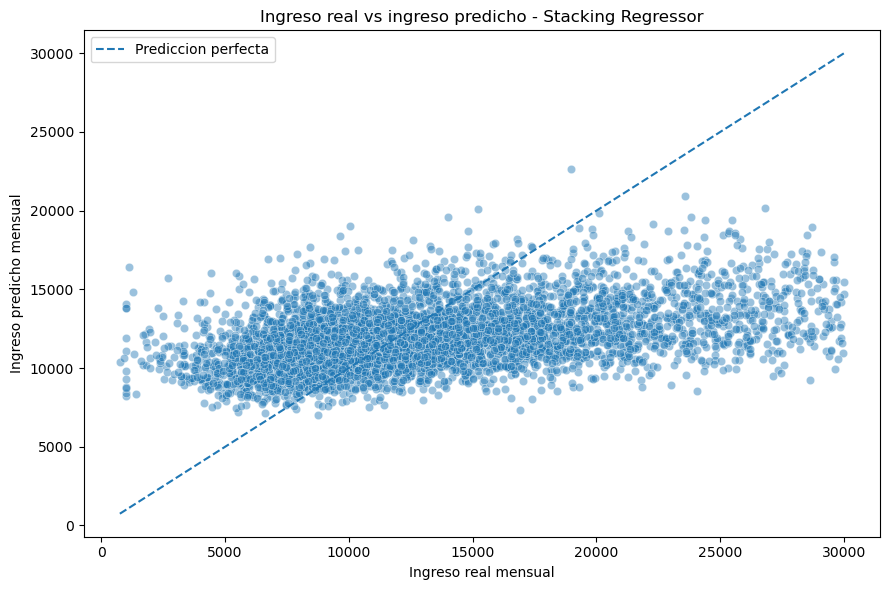

In [63]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_resultados_test,
    x="Ingreso_Real",
    y="Ingreso_Predicho",
    alpha=0.45
)

limites = [
    min(df_resultados_test["Ingreso_Real"].min(), df_resultados_test["Ingreso_Predicho"].min()),
    max(df_resultados_test["Ingreso_Real"].max(), df_resultados_test["Ingreso_Predicho"].max())
]

plt.plot(
    limites,
    limites,
    linestyle="--",
    label="Prediccion perfecta"
)

plt.title("Ingreso real vs ingreso predicho - Stacking Regressor")
plt.xlabel("Ingreso real mensual")
plt.ylabel("Ingreso predicho mensual")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretacion del grafico de ingreso real vs ingreso predicho

Se observa que una proporcion importante de las observaciones se concentra sobre el centro, lo que indica que el modelo es capaz de capturar adecuadamente el comportamiento general de los ingresos de la mayoria de los clientes.

Sin embargo para niveles de ingreso elevados se aprecia una tendencia a la subestimación. Los clientes con ingresos reales muy altos suelen recibir predicciones considerablemente menores a sus valores observados.

Este comportamiento es consistente con la distribucion del problema, ya que los ingresos elevados representan una proporcion reducida de la muestra y presentan una mayor variabilidad. En consecuencia, el modelo logra un mejor desempeño en los rangos de ingreso más frecuentes que en los casos extremos.

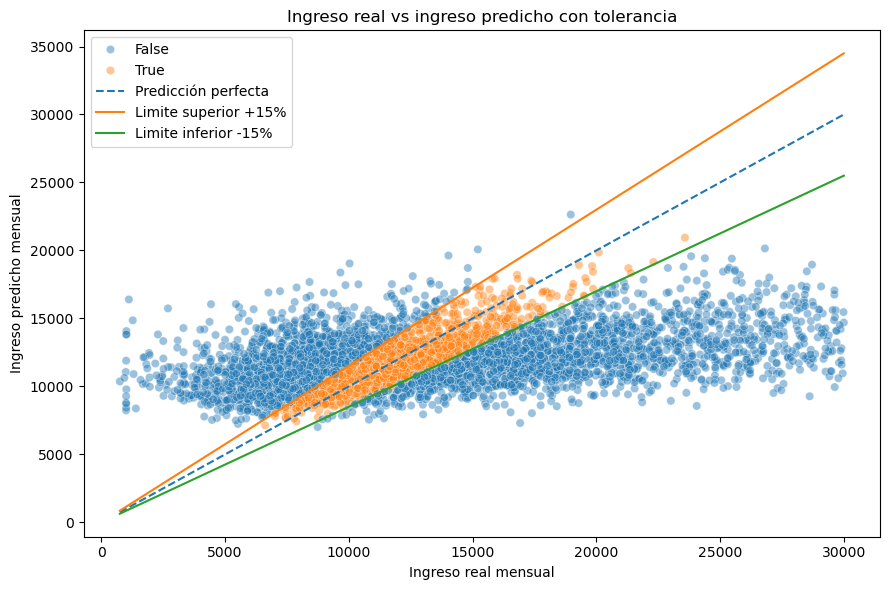

In [64]:
umbral_error = 0.15  #15%

df_resultados_test["Error_Porcentual"] = (#que tan grande fue el error
    df_resultados_test["Error_Absoluto"] / df_resultados_test["Ingreso_Real"]
)

df_resultados_test["Dentro_Banda"] = (
    df_resultados_test["Error_Porcentual"] <= umbral_error
)

limites = [
    min(df_resultados_test["Ingreso_Real"].min(), df_resultados_test["Ingreso_Predicho"].min()),
    max(df_resultados_test["Ingreso_Real"].max(), df_resultados_test["Ingreso_Predicho"].max())
]

x_linea = np.linspace(limites[0], limites[1], 100)

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_resultados_test,
    x="Ingreso_Real",
    y="Ingreso_Predicho",
    hue="Dentro_Banda",
    alpha=0.45
)

plt.plot(
    x_linea,
    x_linea,
    linestyle="--",
    label="Predicción perfecta"
)

plt.plot(
    x_linea,
    x_linea * (1 + umbral_error),
    linestyle="-",
    label=f"Limite superior +{int(umbral_error*100)}%"
)

plt.plot(
    x_linea,
    x_linea * (1 - umbral_error),
    linestyle="-",
    label=f"Limite inferior -{int(umbral_error*100)}%"
)

plt.title("Ingreso real vs ingreso predicho con tolerancia")
plt.xlabel("Ingreso real mensual")
plt.ylabel("Ingreso predicho mensual")
plt.legend()
plt.tight_layout()
plt.show()

In [65]:
df_resultados_test["Tipo_Error"] = np.select(
    [
        df_resultados_test["Dentro_Banda"],
        df_resultados_test["Ingreso_Predicho"] > df_resultados_test["Ingreso_Real"] * (1 + umbral_error),
        df_resultados_test["Ingreso_Predicho"] < df_resultados_test["Ingreso_Real"] * (1 - umbral_error)
    ],
    [
        "Dentro de banda",
        "Sobreestimado",
        "Subestimado"
    ],
    default="Revisar"
)

df_resultados_test["Tipo_Error"].value_counts(normalize=True) * 100

Tipo_Error
Sobreestimado     36.49
Subestimado       34.99
Dentro de banda   28.52
Name: proportion, dtype: float64

In [66]:
df_analisis_error = Xtest.copy()

df_analisis_error["Ingreso_Real"] = df_resultados_test["Ingreso_Real"].values
df_analisis_error["Ingreso_Predicho"] = df_resultados_test["Ingreso_Predicho"].values
df_analisis_error["Error_Absoluto"] = df_resultados_test["Error_Absoluto"].values
df_analisis_error["Error_Porcentual"] = df_resultados_test["Error_Porcentual"].values
df_analisis_error["Dentro_Banda"] = df_resultados_test["Dentro_Banda"].values
df_analisis_error["Tipo_Error"] = df_resultados_test["Tipo_Error"].values

In [67]:
df_analisis_error["Tipo_Error"].value_counts()

Tipo_Error
Sobreestimado      2084
Subestimado        1998
Dentro de banda    1629
Name: count, dtype: int64

Aproximadamente uno de cada tres clientes cae dentro de la banda

In [68]:
df_analisis_error.groupby("Tipo_Error")[
    ["Ingreso_Real", "Ingreso_Predicho", "Error_Absoluto", "Error_Porcentual"]
].agg(["count", "mean", "median", "min", "max"])

Ingreso_Real                                         \
                       count      mean    median      min       max   
Tipo_Error                                                            
Dentro de banda         1629 11,797.29 11,517.17 6,617.54 23,577.94   
Sobreestimado           2084  7,820.84  7,979.71   745.35 18,965.19   
Subestimado             1998 19,099.92 18,413.32 8,737.47 29,997.39   

                Ingreso_Predicho                                         \
                           count      mean    median      min       max   
Tipo_Error                                                                
Dentro de banda             1629 11,690.14 11,390.98 7,132.51 20,940.22   
Sobreestimado               2084 11,578.67 11,356.31 7,235.70 22,637.44   
Subestimado                 1998 12,249.70 11,996.12 7,011.37 20,144.90   

                Error_Absoluto                                       \
                         count     mean   median      min       max   
Tipo_Error                                                            
Dentro de banda           1629   878.54   842.05     0.04  3,153.08   
Sobreestimado             2084 3,757.83 3,287.66 1,191.71 15,286.44   
Subestimado               1998 6,850.22 5,986.03 1,352.77 19,680.60   

                Error_Porcentual                         
                           count mean median  min   max  
Tipo_Error                                               
Dentro de banda             1629 0.07   0.07 0.00  0.15  
Sobreestimado               2084 0.66   0.41 0.15 13.77  
Subestimado                 1998 0.34   0.33 0.15  0.68

El modelo presenta una regresión hacia la media. Cuando hay un ingreso muy bajo lo aumenta y cuando ve un ingreso muy alto lo disminuye. Trata de llevar todas las predicciones hacia una zona cercana a $11,000 - 13,000

La seccion del error absoluto nos indica que el modelo falla mucho mas cuando subestima.

La seccion del error porcentual muestra que los clientes sobreestimados tienen ingresos mucho menores

In [70]:
variables_numericas_analisis = df_analisis_error.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
variables_numericas_analisis = [
    c for c in variables_numericas_analisis
    if c not in [
        "Ingreso_Real",
        "Ingreso_Predicho",
        "Error_Absoluto",
        "Error_Porcentual"
    ]]

resumen_numerico_error = (
    df_analisis_error
    .groupby("Tipo_Error")[variables_numericas_analisis]
    .median()
    .T
)

resumen_numerico_error.head(30)

Tipo_Error,Dentro de banda,Sobreestimado,Subestimado
ANTIGUEDAD_CLIENTE_ANIOS,2.24,2.36,3.01
AVG_FREQ_APER_ANTICIPOS,35.67,36.91,34.67
AVG_FREQ_APER_NCC,95.50,82.00,92.27
AVG_MESES_ENTRE_CUENTAS_APER,39.00,41.89,42.39
AVG_VIGENCIA_ANTICIPOS,0.30,0.32,0.35
AVG_VIGENCIA_NCC,9.00,10.50,8.33
CAP_PAGO_TDC,0.00,0.00,0.00
COUNT_12M,7.00,8.00,8.00
COUNT_6M,4.00,4.00,4.00
COUNT_ANTICIPOS,22.00,19.00,25.00


Caracteristicas que tienen en comun los clientes que el modelo predice correctamente, cuales diferencian a aquellos donde el modelo tiene errores importantes?

In [71]:
import pandas as pd

#medianas por grupo
medianas = (
    df_analisis_error
    .groupby("Tipo_Error")[variables_numericas_analisis]
    .median()
)

#diferencias respecto a dentro de banda
comparacion = pd.DataFrame(index=variables_numericas_analisis)

comparacion["Dentro_Banda"] = medianas.loc["Dentro de banda"]

comparacion["Dif_Sobreestimado"] = (
    medianas.loc["Sobreestimado"] -
    medianas.loc["Dentro de banda"]
)

comparacion["Dif_Subestimado"] = (
    medianas.loc["Subestimado"] -
    medianas.loc["Dentro de banda"]
)

comparacion.head()

,Dentro_Banda,Dif_Sobreestimado,Dif_Subestimado
ANTIGUEDAD_CLIENTE_ANIOS,2.24,0.12,0.76
AVG_FREQ_APER_ANTICIPOS,35.67,1.25,-1.00
AVG_FREQ_APER_NCC,95.50,-13.50,-3.23
AVG_MESES_ENTRE_CUENTAS_APER,39.00,2.89,3.39
AVG_VIGENCIA_ANTICIPOS,0.30,0.02,0.05


Los clientes bien predichos tienen aproximadamente 2.24 km años siendo clientes, mientras que los sobreestimados tienen 2.24 − 0.76 = 1.48 km, no es una diferencia enorme o sobresaliente o algo que encienda alarmas.

In [73]:
comparacion["Cambio_Maximo"] = (
    comparacion[
        ["Dif_Sobreestimado", "Dif_Subestimado"]
    ]
    .abs()
    .max(axis=1)
)

comparacion = comparacion.sort_values(
    "Cambio_Maximo",
    ascending=False
)

comparacion.head(20)

,Dentro_Banda,Dif_Sobreestimado,Dif_Subestimado,Cambio_Maximo
SUM_MONTO_OTORG,"252,528.00","77,926.00","134,870.50","134,870.50"
SUM_TL_SALDO_ACTUAL,"46,611.00","23,658.00","28,167.50","28,167.50"
SUM_LIM_CRED_TDC,"25,400.00","4,075.00","7,826.50","7,826.50"
SUM_SALDO_NCC_ACTUAL,"4,009.00","3,762.00","7,780.00","7,780.00"
SUM_LIM_CRED_TDC_ACTUAL,"12,954.00","3,136.00","1,382.50","3,136.00"
SUM_TL_SALDO_VENCIDO,"3,457.00","2,659.50","2,033.50","2,659.50"
SUM_SDO_VDO_ACTUAL,"8,645.00","1,934.00","1,421.00","1,934.00"
AVG_FREQ_APER_NCC,95.50,-13.50,-3.23,13.50
PCNT_HOSP_PRIV,20.00,0.00,13.33,13.33
MAX_MESES_ENTRE_CUENTAS_APER,135.00,12.00,11.00,12.00


Los clientes correctamente estimados tienen una mediana de $252,528 en monto otorgado. Los sobreestimados tienen 252,528 + 134,870 = 117,658

Los clientes correctamente estimados tienen un saldo activo de $46,611. Los sobreestimados tienen $46,611.6 + 28,167 = $74,778.6. Los subestimados $46,611.6 + $23,658.0 = $70,629. Los clientes donde el modelo falla tienden a ser ligeramente mayores.

### Comparacion de caracteristicas entre clientes correctamente estimados y clientes con mayores errores de prediccion

Con la finalidad de comprender que caracteristicas distinguen a los clientes cuyas predicciones se encuentran dentro de la banda de tolerancia respecto a aquellos donde el modelo presenta errores importantes, se comparo la mediana de cada variable numerica entre los tres grupos analizados.

El grupo **"Dentro de banda"** se tomo como referencia, mientras que las columnas **Dif_Sobreestimado** y **Dif_Subestimado** representan la diferencia de la mediana respecto a dicho grupo.

Los resultados muestran que las mayores diferencias se concentran en variables relacionadas con el comportamiento crediticio del cliente. En particular, **SUM_MONTO_OTORG**, **SUM_TL_SALDO_ACTUAL** y **SUM_LIM_CRED_TDC** presentan incrementos importantes en ambos grupos donde el modelo falla.

Por ejemplo, los clientes correctamente estimados presentan una mediana de aproximadamente **$252,528 MXN** en monto total otorgado, mientras que los clientes sobreestimados y subestimados presentan montos medianos aproximadamente **$78 mil** y **$134 mil** superiores respectivamente.

Un comportamiento similar se observa para el saldo actual y el saldo vencido, lo que sugiere que los clientes con relaciones crediticias mas complejas o con mayor exposicion financiera representan un reto mayor para el modelo.

En contraste variables como la edad, la distancia al trabajo, los tiempos de traslado o algunos conteos presentan diferencias relativamente pequeñas entre grupos, lo que indica que probablemente tienen una menor capacidad para explicar los errores de prediccion observados.

In [74]:
comparacion["Cambio_%_Sobre"] = (
    comparacion["Dif_Sobreestimado"] /
    comparacion["Dentro_Banda"]
) * 100

comparacion["Cambio_%_Sub"] = (
    comparacion["Dif_Subestimado"] /
    comparacion["Dentro_Banda"]
) * 100

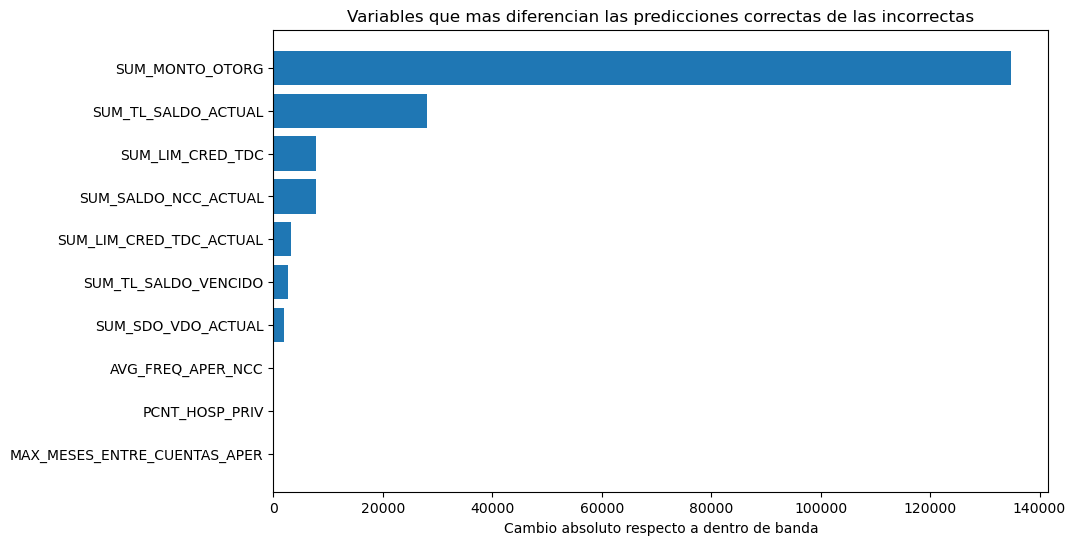

In [75]:
top10 = comparacion.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10.index,
    top10["Cambio_Maximo"]
)

plt.xlabel("Cambio absoluto respecto a dentro de banda")
plt.title("Variables que mas diferencian las predicciones correctas de las incorrectas")

plt.gca().invert_yaxis()

plt.show()

In [76]:
comparacion_relativa = comparacion.copy()

comparacion_relativa["Cambio_%_Sobreestimado"] = (
    comparacion_relativa["Dif_Sobreestimado"] /
    comparacion_relativa["Dentro_Banda"]
) * 100

comparacion_relativa["Cambio_%_Subestimado"] = (
    comparacion_relativa["Dif_Subestimado"] /
    comparacion_relativa["Dentro_Banda"]
) * 100

comparacion_relativa["Cambio_%_Maximo"] = (
    comparacion_relativa[
        ["Cambio_%_Sobreestimado", "Cambio_%_Subestimado"]
    ] 
    .abs()
    .max(axis=1))

comparacion_relativa = comparacion_relativa.sort_values(
    "Cambio_%_Maximo",
    ascending=False)

comparacion_relativa.head(20)

,Dentro_Banda,Dif_Sobreestimado,Dif_Subestimado,Cambio_Maximo,Cambio_%_Sobre,Cambio_%_Sub,Cambio_%_Sobreestimado,Cambio_%_Subestimado,Cambio_%_Maximo
SUM_SALDO_NCC_ACTUAL,"4,009.00","3,762.00","7,780.00","7,780.00",93.84,194.06,93.84,194.06,194.06
COUNT_FLAG_CC,1.00,0.00,1.00,1.00,0.00,100.00,0.00,100.00,100.00
SUM_TL_SALDO_VENCIDO,"3,457.00","2,659.50","2,033.50","2,659.50",76.93,58.82,76.93,58.82,76.93
PCNT_HOSP_PRIV,20.00,0.00,13.33,13.33,0.00,66.67,0.00,66.67,66.67
FLAG_ANTICIPO_NOMINA,0.75,0.23,0.49,0.49,30.88,66.18,30.88,66.18,66.18
SUM_TL_SALDO_ACTUAL,"46,611.00","23,658.00","28,167.50","28,167.50",50.76,60.43,50.76,60.43,60.43
SUM_MONTO_OTORG,"252,528.00","77,926.00","134,870.50","134,870.50",30.86,53.41,30.86,53.41,53.41
RATIO_SALDO_VENCIDO_ACTUAL,0.05,0.02,0.00,0.02,37.98,5.79,37.98,5.79,37.98
ANTIGUEDAD_CLIENTE_ANIOS,2.24,0.12,0.76,0.76,5.37,33.94,5.37,33.94,33.94
SUM_LIM_CRED_TDC,"25,400.00","4,075.00","7,826.50","7,826.50",16.04,30.81,16.04,30.81,30.81


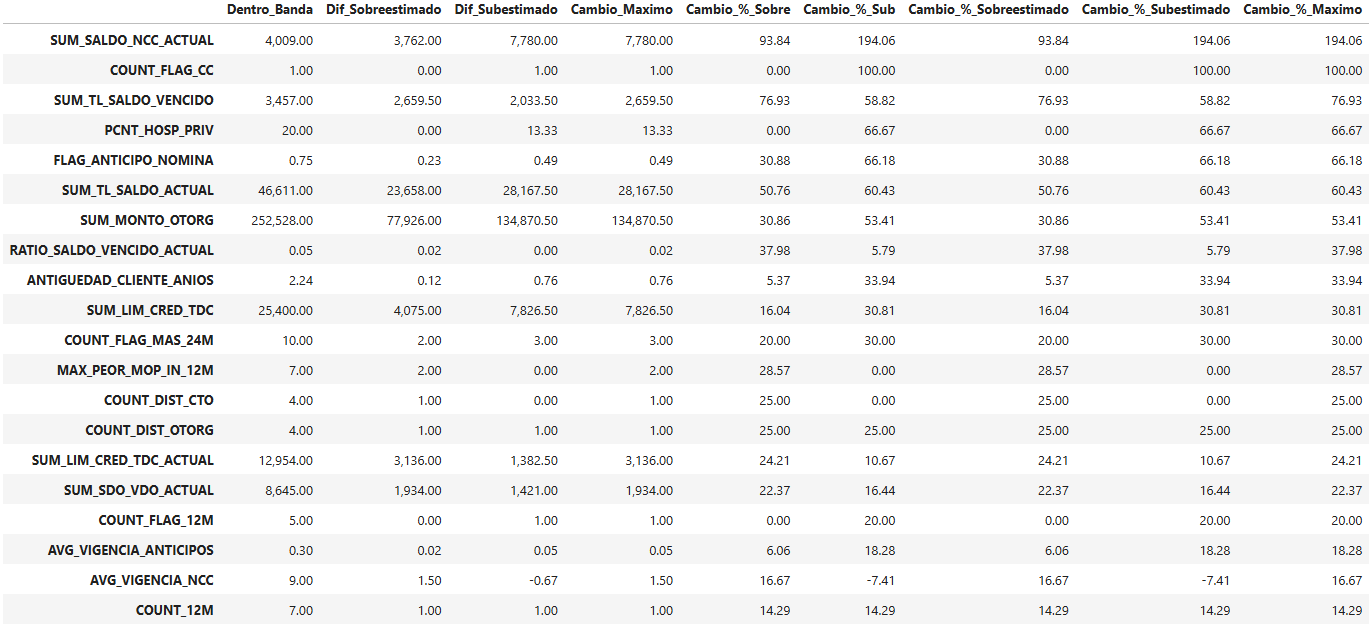

### Comparacion relativa de las caracteristicas entre clientes correctamente estimados y clientes con errores de prediccion

Con la finalidad de realizar una comparacion mas justa entre variables medidas en diferentes unidades (pesos, años, porcentajes, conteos o indicadores), las diferencias observadas respecto al grupo **"Dentro de banda"** se normalizaron expresandolas como porcentaje del valor mediano de dicho grupo.

Esta transformacion permite identificar que variables presentan los mayores cambios relativos independientemente de su escala de medicion, facilitando la comparacion entre caracteristicas financieras, demograficas y de contexto.

Los resultados muestran que las mayores diferencias corresponden principalmente a variables relacionadas con el comportamiento financiero del cliente. En particular, el **saldo actual de creditos de nomina (SUM_SALDO_NCC_ACTUAL)** presenta el mayor cambio relativo, alcanzando un incremento cercano al **194%** en los clientes subestimados respecto al grupo correctamente estimado. De forma similar, el **numero historico de tarjetas de credito (COUNT_FLAG_CC)**, el **saldo total vencido (SUM_TL_SALDO_VENCIDO)** y el **porcentaje de hospitales privados cercanos a la vivienda del cliente (PCNT_HOSP_PRIV)** muestran incrementos aproximados del **100%**, **77%** y **67%**, respectivamente.

Asimismo variables como el **indicador de anticipos de nomina (FLAG_ANTICIPO_NOMINA)**, el **saldo actual total (SUM_TL_SALDO_ACTUAL)** y el **monto total otorgado (SUM_MONTO_OTORG)** presentan incrementos superiores al **50%**, lo que sugiere que los clientes donde el modelo presenta mayores errores suelen mostrar una actividad financiera mas intensa y un perfil crediticio mas complejo que aquellos cuyas predicciones permanecen dentro de la banda de tolerancia.

En conjunto estos resultados indican que el modelo presenta un mejor desempeño sobre clientes con caracteristicas financieras mas representativas del conjunto de entrenamiento, mientras que tiende a presentar mayores errores cuando evalua clientes con niveles considerablemente mas altos de actividad crediticia, saldos o montos otorgados. De igual forma, algunas variables de contexto, como la proporcion de hospitales privados en el entorno del cliente, tambien muestran diferencias relevantes entre grupos, lo que sugiere que las condiciones socioeconomicas del entorno pueden aportar informacion complementaria para explicar parte de los errores de prediccion observados. En general, estos hallazgos son consistentes con la regresion hacia la media identificado previamente, donde las predicciones tienden a concentrarse alrededor del comportamiento promedio del segmento analizado.

### Grafico 2 - Analisis de residuos

Los residuos representan la diferencia entre el ingreso real y el ingreso estimado por el modelo.

Este grafico permite identificar posibles patrones sistematicos en los errores. Idealmente los residuos deberian distribuirse aleatoriamente alrededor de cero.

La presencia de patrones definidos podria indicar que existen relaciones que el modelo aun no logra capturar adecuadamente.

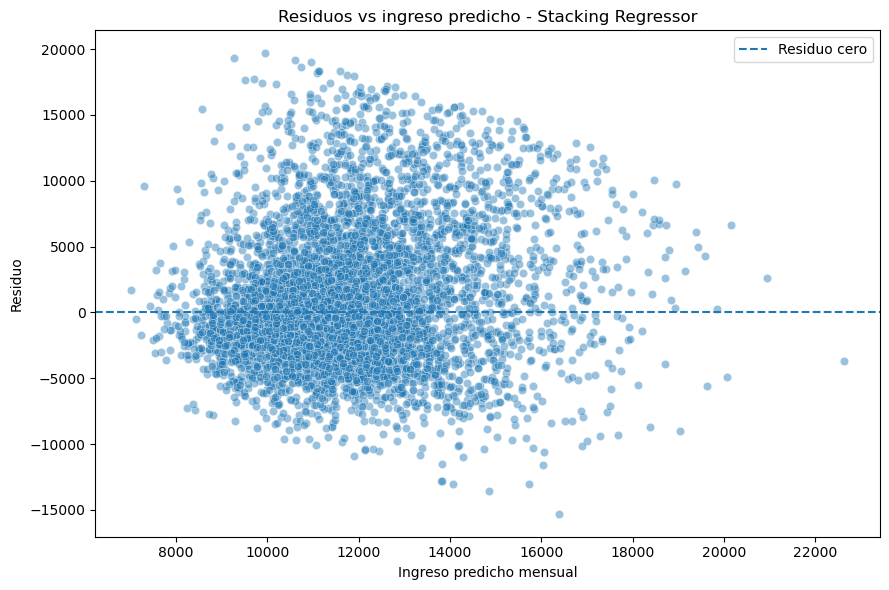

In [77]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_resultados_test,
    x="Ingreso_Predicho",
    y="Residuo",
    alpha=0.45
)

plt.axhline(
    y=0,
    linestyle="--",
    label="Residuo cero"
)

plt.title("Residuos vs ingreso predicho - Stacking Regressor")
plt.xlabel("Ingreso predicho mensual")
plt.ylabel("Residuo")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretacion del grafico de residuos

Los residuos se distribuyen alrededor de cero sin presentar patrones lineales evidentes, lo que nos sugiere que el modelo captura una parte importante de la señal presente en los datos.

Sin embargo se observa un incremento en la dispersion de los residuos conforme aumentan los ingresos estimados. Este comportamiento indica la presencia de heterocedasticidad, elcual es un fenomeno frecuente en problemas financieros donde los clientes de mayores ingresos suelen presentar una variabilidad mas alta.

Tambien se aprecia una mayor cantidad de residuos positivos extremos, lo que sugiere una tendencia del modelo a subestimar algunos clientes de ingresos elevados.

### Grafico 3 - Distribucion de residuos

La distribucion de residuos permite analizar el comportamiento global de los errores del modelo.

Un modelo adecuadamente calibrado suele presentar residuos centrados alrededor de cero, sin sesgos evidentes hacia sobreestimacion o subestimacion sistematica.

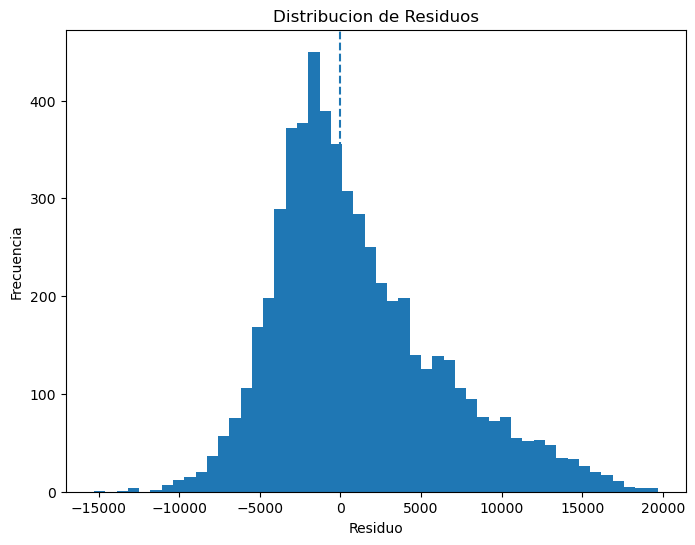

In [78]:
plt.figure(figsize=(8,6))

plt.hist(
    residuos,
    bins=50
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.xlabel("Residuo")
plt.ylabel("Frecuencia")

plt.title("Distribucion de Residuos")

plt.show()

### Interpretacion de la distribucion de residuos

La distribucion de residuos se encuentra concentrada alrededor de cero, indicando que la mayoría de las predicciones presentan errores moderados.

Sin embargo se observa una asimetria positiva, que se caracteriza por una cola mas extensa hacia valores positivos. Este resultado indica que existen algunos clientes para los cuales el ingreso real supera ampliamente la prediccion generada por el modelo.

La evidencia es consistente con los resultados observados en los gráficos anteriores y sugiere que los errores mas importantes se concentran en clientes con ingresos elevados.

### Grafico 4 - Error absoluto por nivel de ingreso

Este grafico permite evaluar si el desempeño del modelo es consistente a traves de distintos niveles de ingreso.

Esta comparacion es relevante porque los clientes de ingresos altos suelen presentar una mayor variabilidad financiera que los clientes de ingresos bajos o medios.

Si se observan diferencias importantes entre grupos, podrian proponerse mejoras futuras mediante segmentacion o modelos especializados.

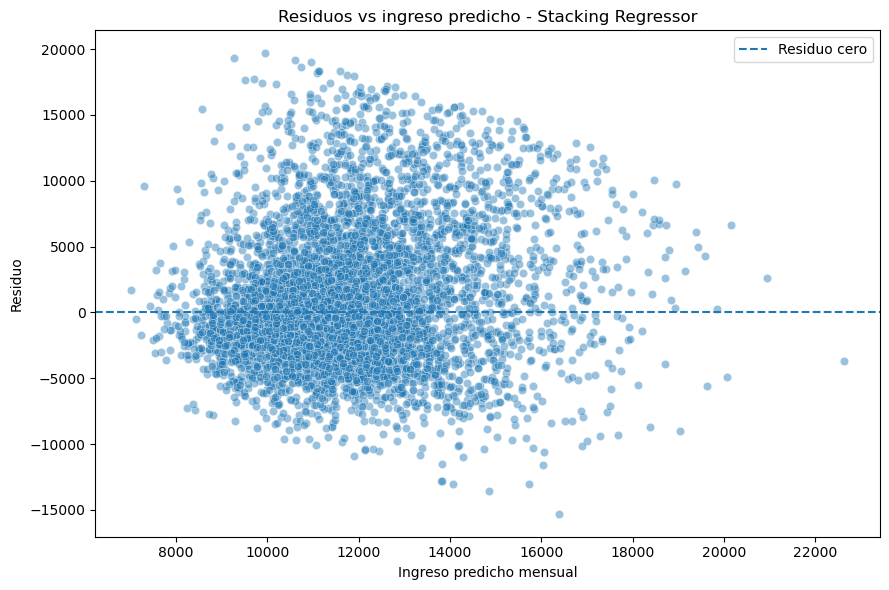

In [79]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_resultados_test,
    x="Ingreso_Predicho",
    y="Residuo",
    alpha=0.45
)

plt.axhline(
    y=0,
    linestyle="--",
    label="Residuo cero"
)

plt.title("Residuos vs ingreso predicho - Stacking Regressor")
plt.xlabel("Ingreso predicho mensual")
plt.ylabel("Residuo")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretacion del error absoluto por nivel de ingreso

El error absoluto promedio se mantiene relativamente estable en los primeros deciles de ingreso, lo que indica un desempeño consistente para la mayor parte de la poblacion analizada.

Sin embargo el error aumenta de manera considerable en los deciles superiores, especialmente en el ultimo grupo de ingresos. Este comportamiento es esperable debido a la menor cantidad de observaciones disponibles y a la mayor variabilidad asociada a clientes de ingresos elevados.

Desde la perspectiva del negocio este resultado no invalida la utilidad de nuestro modelo, ya que el objetivo principal consiste en identificar posibles inconsistencias entre ingresos declarados e ingresos estimados, mas que calcular de manera exacta el ingreso de cada cliente.

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


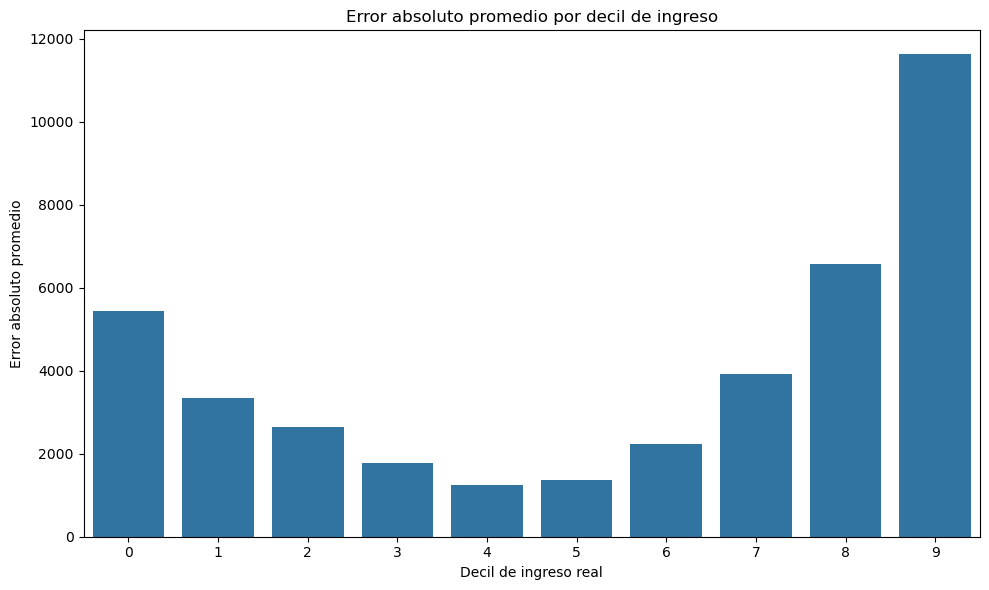

In [92]:
df_resultados_test["Decil_Ingreso"] = pd.qcut(
    df_resultados_test["Ingreso_Real"],
    q=10,
    labels=False
)

error_por_decil = (
    df_resultados_test
    .groupby("Decil_Ingreso", as_index=False)["Error_Absoluto"]
    .mean()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=error_por_decil,
    x="Decil_Ingreso",
    y="Error_Absoluto"
)

plt.title("Error absoluto promedio por decil de ingreso")
plt.xlabel("Decil de ingreso real")
plt.ylabel("Error absoluto promedio")
plt.tight_layout()
plt.show()

### Interpretacion del grafico de ingreso real vs ingreso predicho (zoom al 99% de clientes)

La version ampliada del grafico permite analizar con mayor detalle el comportamiento del modelo sobre la gran mayoria de los clientes, eliminando únicamente el 1% de observaciones con ingresos mas altos para mejorar la visualizacion.

Se observa que el modelo logra capturar adecuadamente la tendencia general de los ingresos, ya que conforme aumenta el ingreso real también aumenta el ingreso estimado. Esto confirma la existencia de señal predictiva en los datos utilizados.

Tambien se aprecia que la dispersion de las predicciones aumenta para niveles de ingreso mas elevados. Este comportamiento es consistente con la naturaleza de nuestro problema dado que los clientes de ingresos altos suelen presentar una mayor heterogeneidad financiera.

Por ultimo, puede observarse que una parte importante de los clientes con ingresos relativamente altos se ubican por debajo de la linea de prediccion perfecta, lo que indica una tendencia del modelo a subestimar algunos ingresos elevados. Este comportamiento también fue identificado en los analisis de residuos realizados previamente.

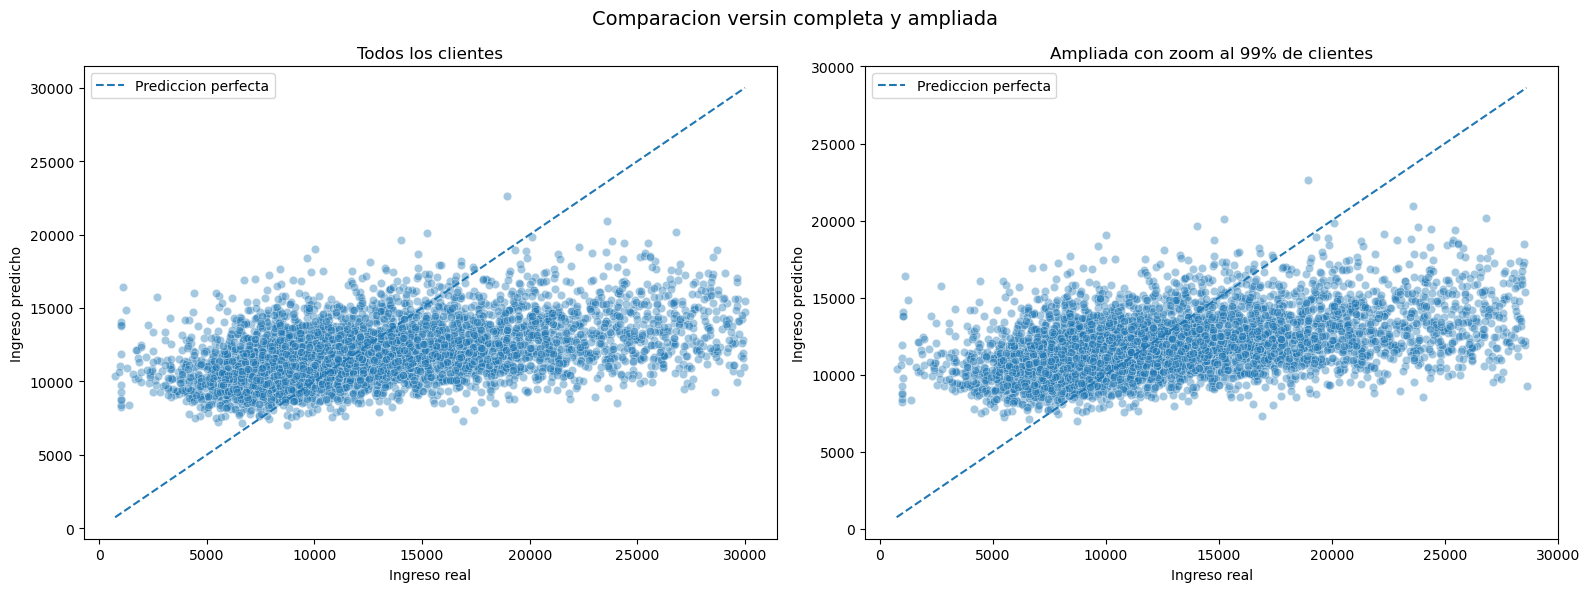

In [81]:
limite_zoom = df_resultados_test["Ingreso_Real"].quantile(0.99)

df_zoom = df_resultados_test[
    df_resultados_test["Ingreso_Real"] <= limite_zoom
].copy()

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16,6)
)

# grafico completo

sns.scatterplot(
    data=df_resultados_test,
    x="Ingreso_Real",
    y="Ingreso_Predicho",
    alpha=0.4,
    ax=axes[0]
)

limites = [
    min(
        df_resultados_test["Ingreso_Real"].min(),
        df_resultados_test["Ingreso_Predicho"].min()
    ),
    max(
        df_resultados_test["Ingreso_Real"].max(),
        df_resultados_test["Ingreso_Predicho"].max()
    )
]

axes[0].plot(
    limites,
    limites,
    linestyle="--",
    label="Prediccion perfecta"
)

axes[0].set_title(
    "Todos los clientes"
)

axes[0].set_xlabel(
    "Ingreso real"
)

axes[0].set_ylabel(
    "Ingreso predicho"
)

axes[0].legend()

# grafica aumentada zoom

sns.scatterplot(
    data=df_zoom,
    x="Ingreso_Real",
    y="Ingreso_Predicho",
    alpha=0.4,
    ax=axes[1]
)

limites_zoom = [
    min(
        df_zoom["Ingreso_Real"].min(),
        df_zoom["Ingreso_Predicho"].min()
    ),
    max(
        df_zoom["Ingreso_Real"].max(),
        df_zoom["Ingreso_Predicho"].max()
    )
]

axes[1].plot(
    limites_zoom,
    limites_zoom,
    linestyle="--",
    label="Prediccion perfecta"
)

axes[1].set_title(
    "Ampliada con zoom al 99% de clientes"
)

axes[1].set_xlabel(
    "Ingreso real"
)

axes[1].set_ylabel(
    "Ingreso predicho"
)

axes[1].legend()

plt.suptitle(
    "Comparacion versin completa y ampliada",
    fontsize=14
)

plt.tight_layout()

plt.show()

### Comparacion

La grafica de la izquierda muestra el comportamiento del modelo sobre la totalidad de las observaciones disponibles. Debido a la presencia de clientes con ingresos significativamente superiores al promedio la escala se expande considerablemente y dificulta la observacion detallada de la mayoria de los casos.

La grafica de la derecha presenta una version ampliada que excluye unicamente el 1% superior de ingresos para fines de visualizacion. Esto permite analizar con mayor claridad el comportamiento del modelo sobre la mayor parte de la poblacion.

La comparacion nos evidencia que el modelo captura adecuadamente la tendencia general de los ingresos, aunque persisten algunas dificultades para estimar con precision algunos clientes de ingresos elevados.

In [82]:
from sklearn.inspection import permutation_importance

#importancia de cada variable
perm_importance = permutation_importance(
    stacking_pipeline, #preprocesamiento + Stacking regressor
    Xtest,
    ytest, #ingreso en escala logaritmica
    n_repeats=10, #cada veriable desordenada 10 veces
    random_state=42,
    scoring="r2", #cuanto va a caer R2 cuando se desordena una variable en especifico
    n_jobs=-1
)

In [84]:
feature_names = Xtest.columns

importancias = pd.DataFrame({
    "Variable": feature_names,
    "Importancia Media": perm_importance.importances_mean,
    "Importancia Std": perm_importance.importances_std
})

importancias = importancias.sort_values(
    by="Importancia Media",
    ascending=False
).reset_index(drop=True)

top20_importancias = importancias.head(20)

top20_importancias

,Variable,Importancia Media,Importancia Std
0,COUNT_ANTICIPOS,0.02,0.00
1,ANTIGUEDAD_CLIENTE_ANIOS,0.02,0.00
2,SEXO,0.02,0.00
3,SUM_MONTO_OTORG,0.02,0.00
4,FREQ_DEP,0.01,0.00
5,COUNT_FLAG_CC,0.01,0.00
6,COUNT_FLAG_SALDO_VDO,0.01,0.00
7,SUM_LIM_CRED_TDC,0.01,0.00
8,COUNT_AUTOCONS,0.01,0.00
9,RATIO_SALDO_ACTUAL_MONTO,0.01,0.00


### Interpretacion

La variable con mayor importancia para el modelo final fue `COUNT_ANTICIPOS`, variable que tiene mucha relación con el ingreso, ya que los clientes que más suelen disponer de este tipo de créditos son los clientes cuyos ingresos son relativamente insuficientes para sus gastos, lo que genera que soliciten estos créditos

Tambien se identificaron como relevantes variables asociadas a la frecuencia y estabilidad de los depositos, como `FREQ_DEP` y `ANTIGUEDAD_CLIENTE_ANIOS`. Estas variables pueden capturar patrones relacionados con estabilidad laboral, recurrencia de ingresos y comportamiento de nomina.

Adicionalmente aparecen variables crediticias como `COUNT_AUTOCONS`, `COUNT_FLAG_SALDO_VDO`, `COUNT_FLAG_OPEN` y `RATIO_SALDO_ACTUAL_MONTO`, lo que sugiere que el modelo aprovecha informacion de comportamiento financiero e historial crediticio para complementar la estimacion de ingresos.

Variables sociodemograficas y geograficas, como `REGION`, `SEXO`, `EDAD` y `min_dist_n_hospitales_priv`, tambien aportan informacion aunque con menor importancia relativa.

En conjunto los resultados muestran que el modelo final utiliza principalmente variables financieras, crediticias y de comportamiento de nomina lo cual es coherente con el objetivo de estimar ingresos mediante informacion observable y alternativa.

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


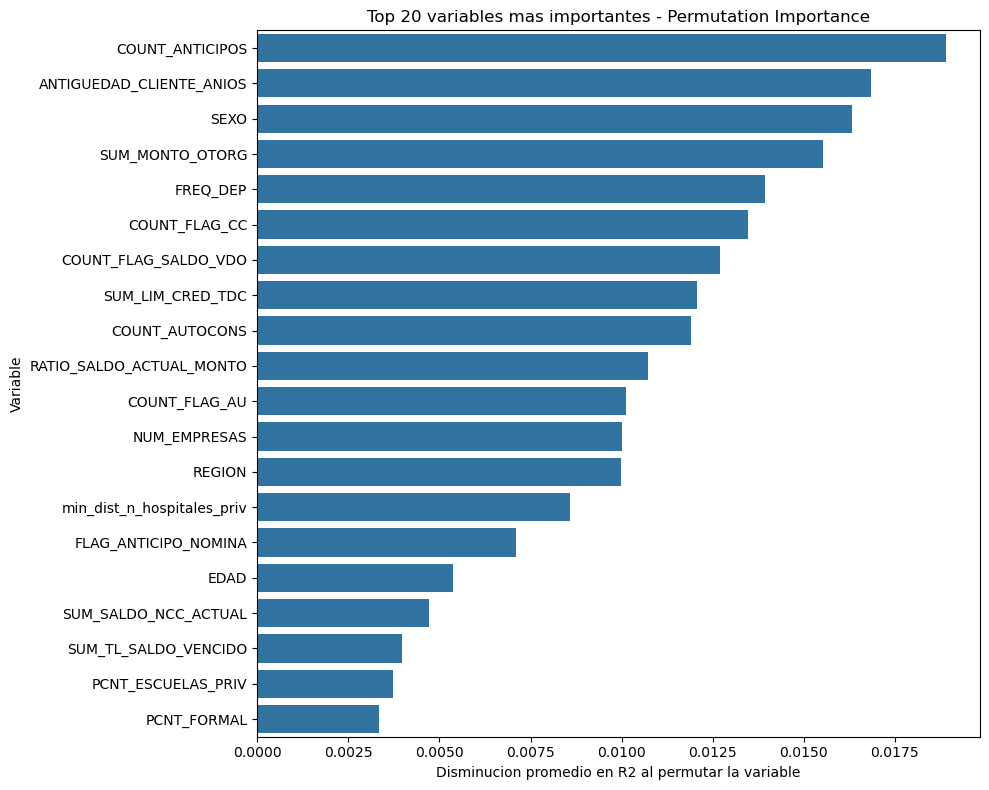

In [85]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=top20_importancias,
    x="Importancia Media",
    y="Variable"
)

plt.title("Top 20 variables mas importantes - Permutation Importance")
plt.xlabel("Disminucion promedio en R2 al permutar la variable")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()